In [8]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import json
# from matplotlib import colormaps
import re
import io
from datetime import datetime
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
import glob, natsort, os

from src.metadata_utils import extract_metadata
from src.metadata_utils import DHM_data_extraction
from src.metadata_utils import fatigue_data_extraction
from src.metadata_utils import fatigue_dataframe_extraction
from src.Plot import main_plot
from src.Plot import Plot_single_DHM
from src.Plot import Plot_multi_DHM

#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# This code is used to plot the data from the FE tester for the CV
#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

%config InlineBackend.figure_format = 'retina' # For high resolution figures in Jupyter Notebook
#%matplotlib widget

---

## Operator window

#### Parameters to Specify

- **Input file path**  
- **Output file path**  
- **File name**  
- **Number of points to remove** (in case of breakdown)
- **1 or 0 if you want a video from the DHM plot** (may take a long time if nemerous plot are present)

⚠️ **Important:** Pay attention to the **output path**. The program will automatically create **4 subfolders** in the output path to store the plots, a video and the CSV file.

In [9]:
# Set the path to the data file
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

file_path = r'E:\Nextcloud\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_05\Endurance - DHM'
output_path = r'E:\Nextcloud\06 - FeCAP-FTJ\02 - Data\02 - FE tester\NASA_FeCAP_05\Endurance - DHM'
file_name = 'NASA_FeCAP_05_ID20-06_FM.dat'
full_path = os.path.join(file_path, file_name)

# If we have a breakdown during the measurement, we can remove the last n points
point_removal = 0

# 1 if you want a video from the DHM plot (may take a long time if nemerous plot are present), 0 otherwise
video_allowed = 0 

# Extract the last folder name from the file path
last_folder = os.path.basename(os.path.dirname(file_path))
print(last_folder)

# Séparer nom et extension
base_name = os.path.splitext(file_name)[0]
print(base_name)  # ➜ NASA_SL_ALE_10_ID_095

NASA_FeCAP_05
NASA_FeCAP_05_ID20-06_FM


---

## Complete fatigue analysis

File extraction

In [10]:
# The function used in this cell are stored in the src folder

# --- Get the lines where the information of the fatigue measurement are stored ---
data_lines_complete_fatigue = fatigue_data_extraction(full_path)

# --- Initialize metadata placeholders ---
metadata_dict_DHM, metadata_dict_CVM, metadata_dict_PUND, metadata_str_DHM, metadata_str_CVM, metadata_str_PUND = extract_metadata(data_lines_complete_fatigue, point_removal, keyword="Hysteresis")

# --- Extract the dataframe of the fatigue measurement into a pandas series to plot the curves ---
df_fatigue_DHM, df_fatigue_CVM, df_fatigue_PUND, Cycles_total = fatigue_dataframe_extraction(data_lines_complete_fatigue, point_removal, metadata_dict_DHM, metadata_dict_CVM, metadata_dict_PUND)


Found the start of the table block at line 10: Result Table 1
Found the end of the table block at line 72: Data Table [1,1]
Data header found at relative line 20, end marker at 36


Main Plot

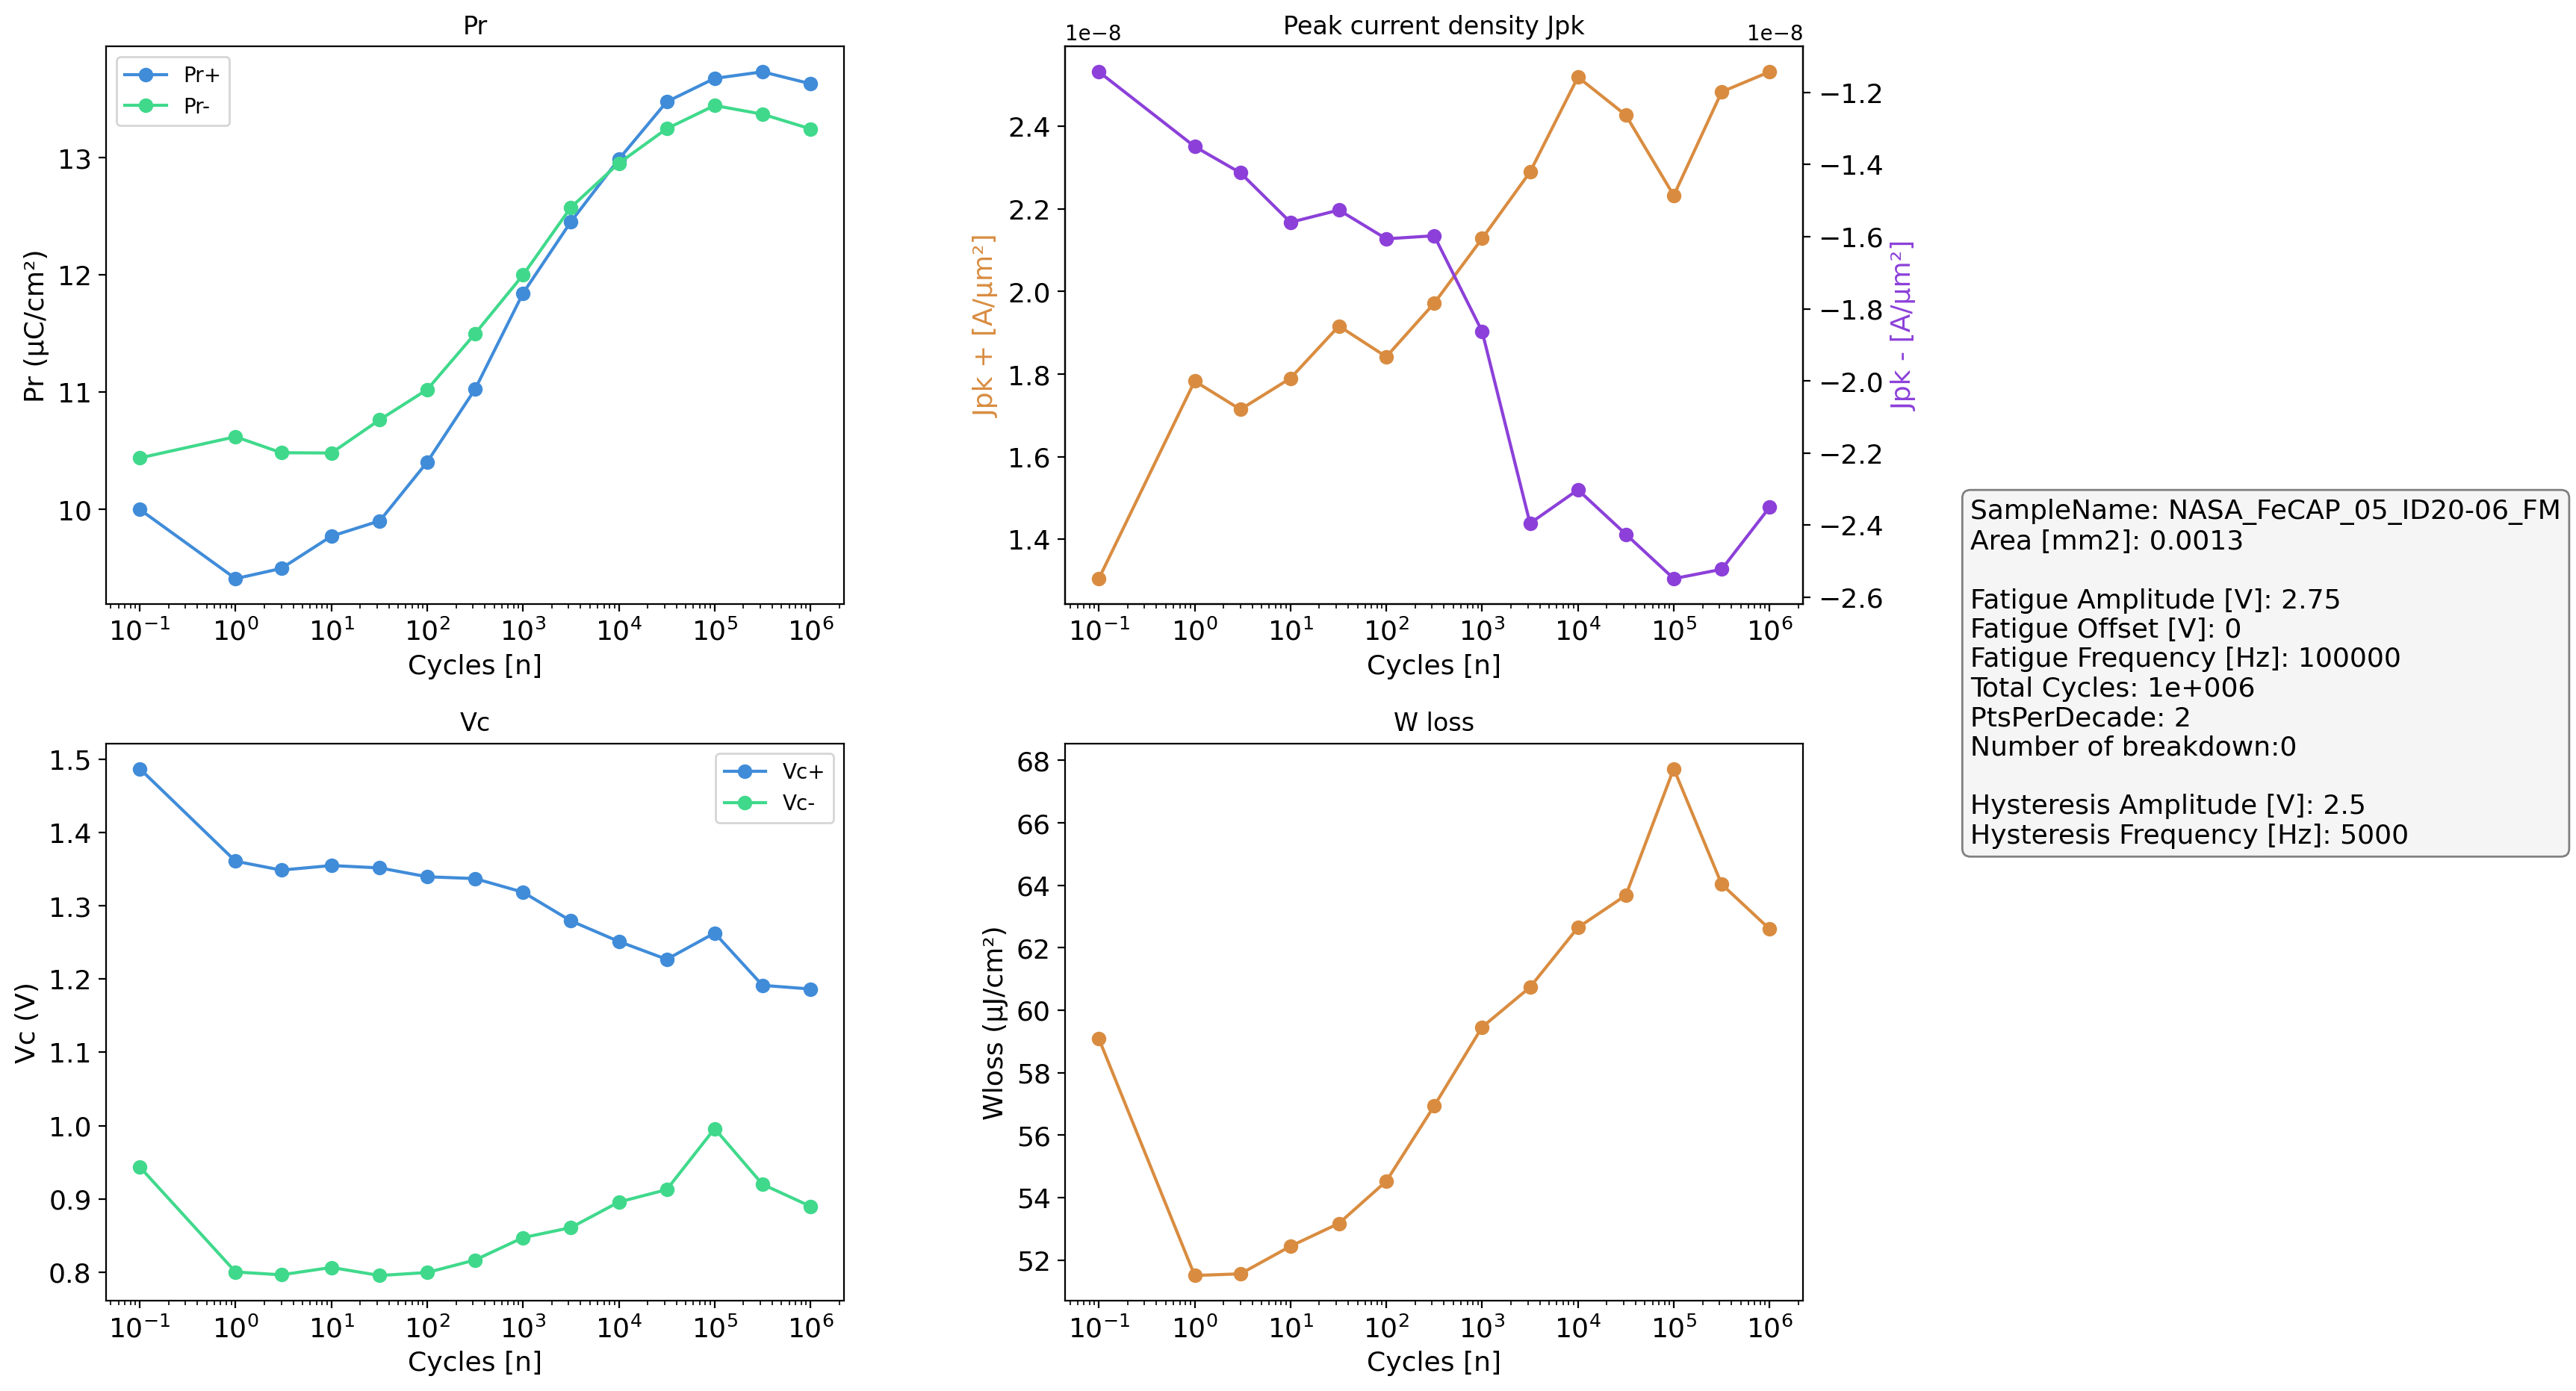

In [11]:
# --- Plot the fatigue data ---

label_size = 13
Save_main_plot = True

main_plot(df_fatigue_DHM, df_fatigue_CVM, df_fatigue_PUND, metadata_dict_DHM, metadata_dict_CVM, metadata_dict_PUND, metadata_str_DHM, metadata_str_CVM, metadata_str_PUND, output_path, base_name, label_size)

output_path_02 = os.path.join(output_path, base_name)
os.makedirs(output_path_02, exist_ok=True)  # Ensure output directory exists
output_main_plot = os.path.join(output_path_02, "Main plot")
os.makedirs(output_main_plot, exist_ok=True)  # Ensure output directory exists


---

## DHM analysis

Data analysis

In [12]:

DHM_dataframe = DHM_data_extraction(full_path, Cycles_total, point_removal, df_fatigue_DHM)

#Concatenate all DataFrames into a single DataFrame and save to CSV
DHM_dataframe_csv = pd.concat(DHM_dataframe, axis=1)
output_csv_data_path = os.path.join(output_path_02, "CSV data")
os.makedirs(output_csv_data_path, exist_ok=True)  # Ensure output directory exists

DHM_dataframe_csv.to_csv(os.path.join(output_csv_data_path, f"{metadata_dict_DHM["Measurement_date_iso"]}_{base_name}_FatigueDHM.csv"), index=False)


14 P-V loops loaded.


Single plot

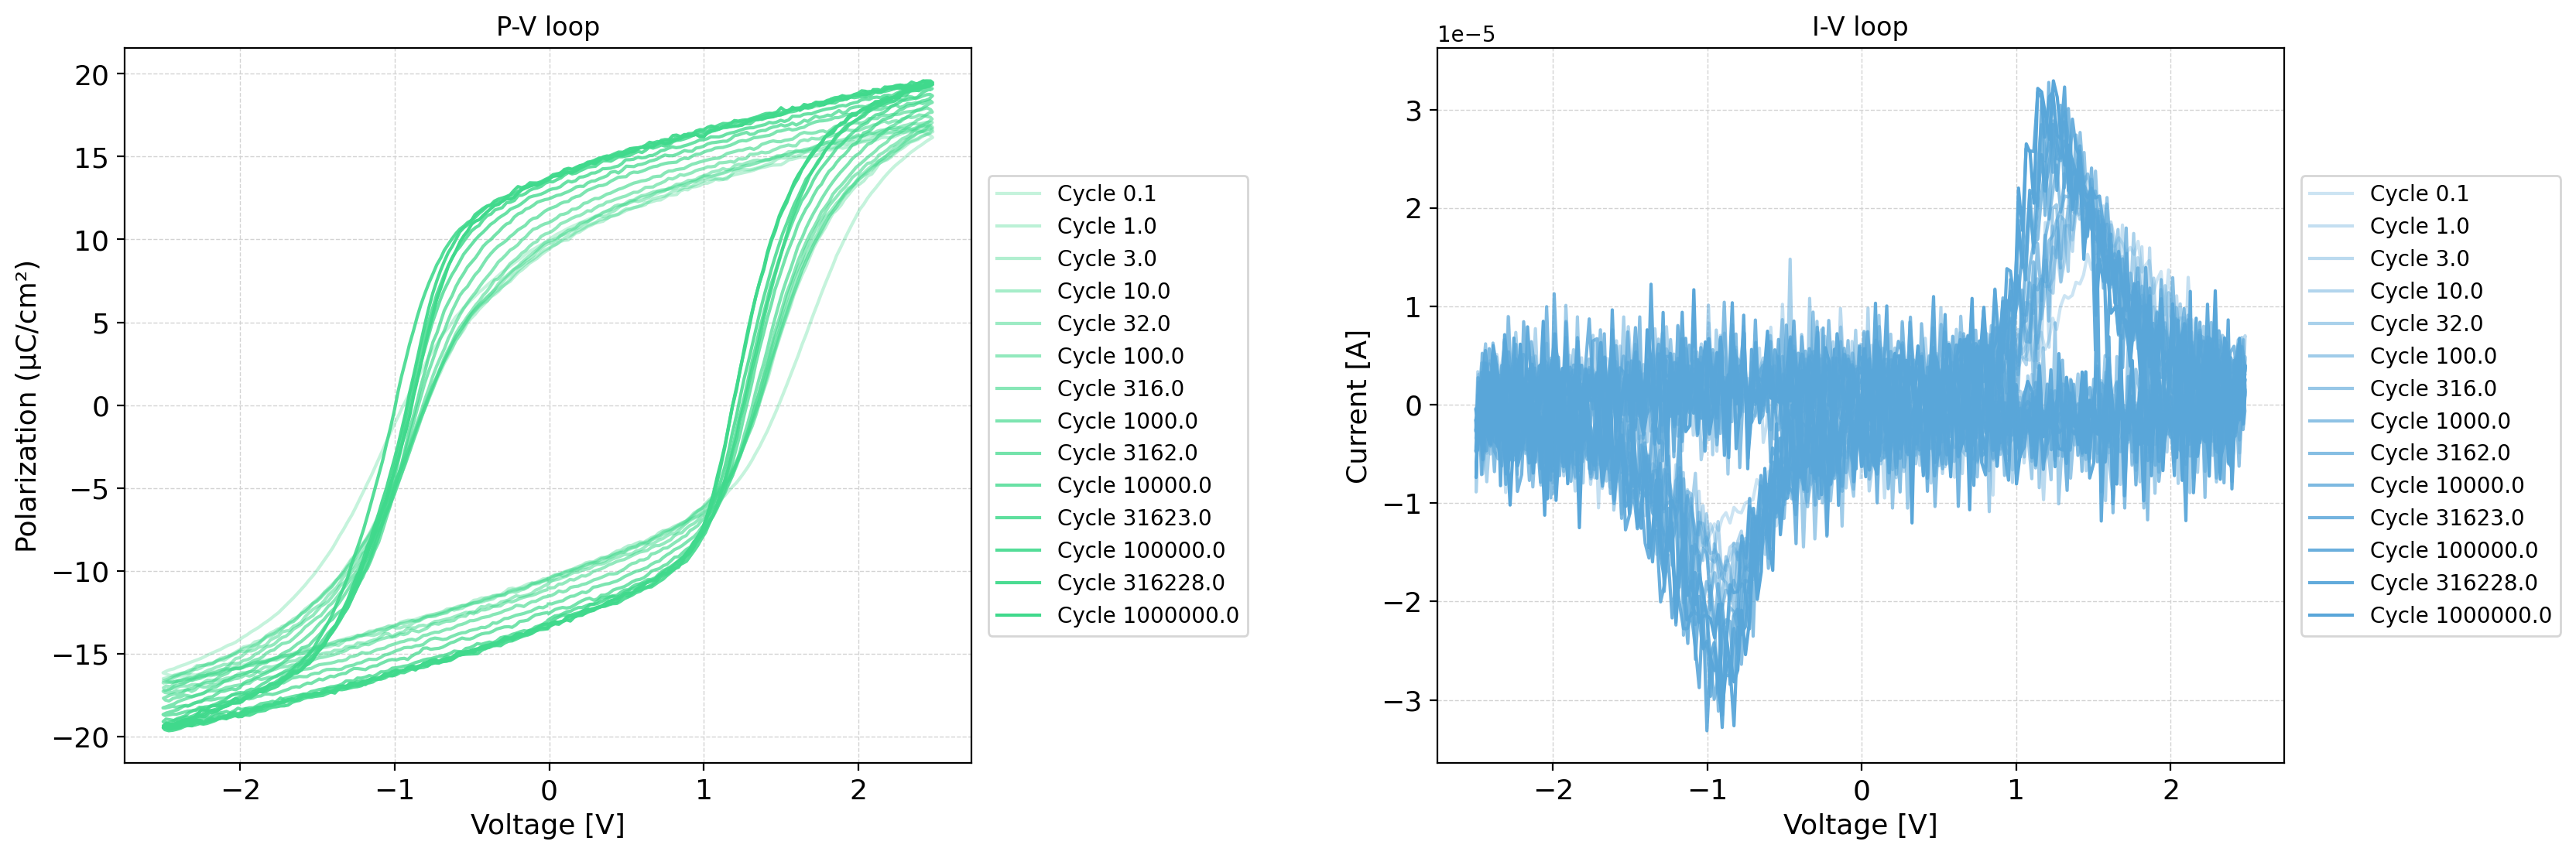

In [13]:
# Ploting of every DHM curve into a single plot.

label_size = 13
Plot_single_DHM(DHM_dataframe, Cycles_total, label_size, output_main_plot, base_name, metadata_dict_DHM)

Multi-plot

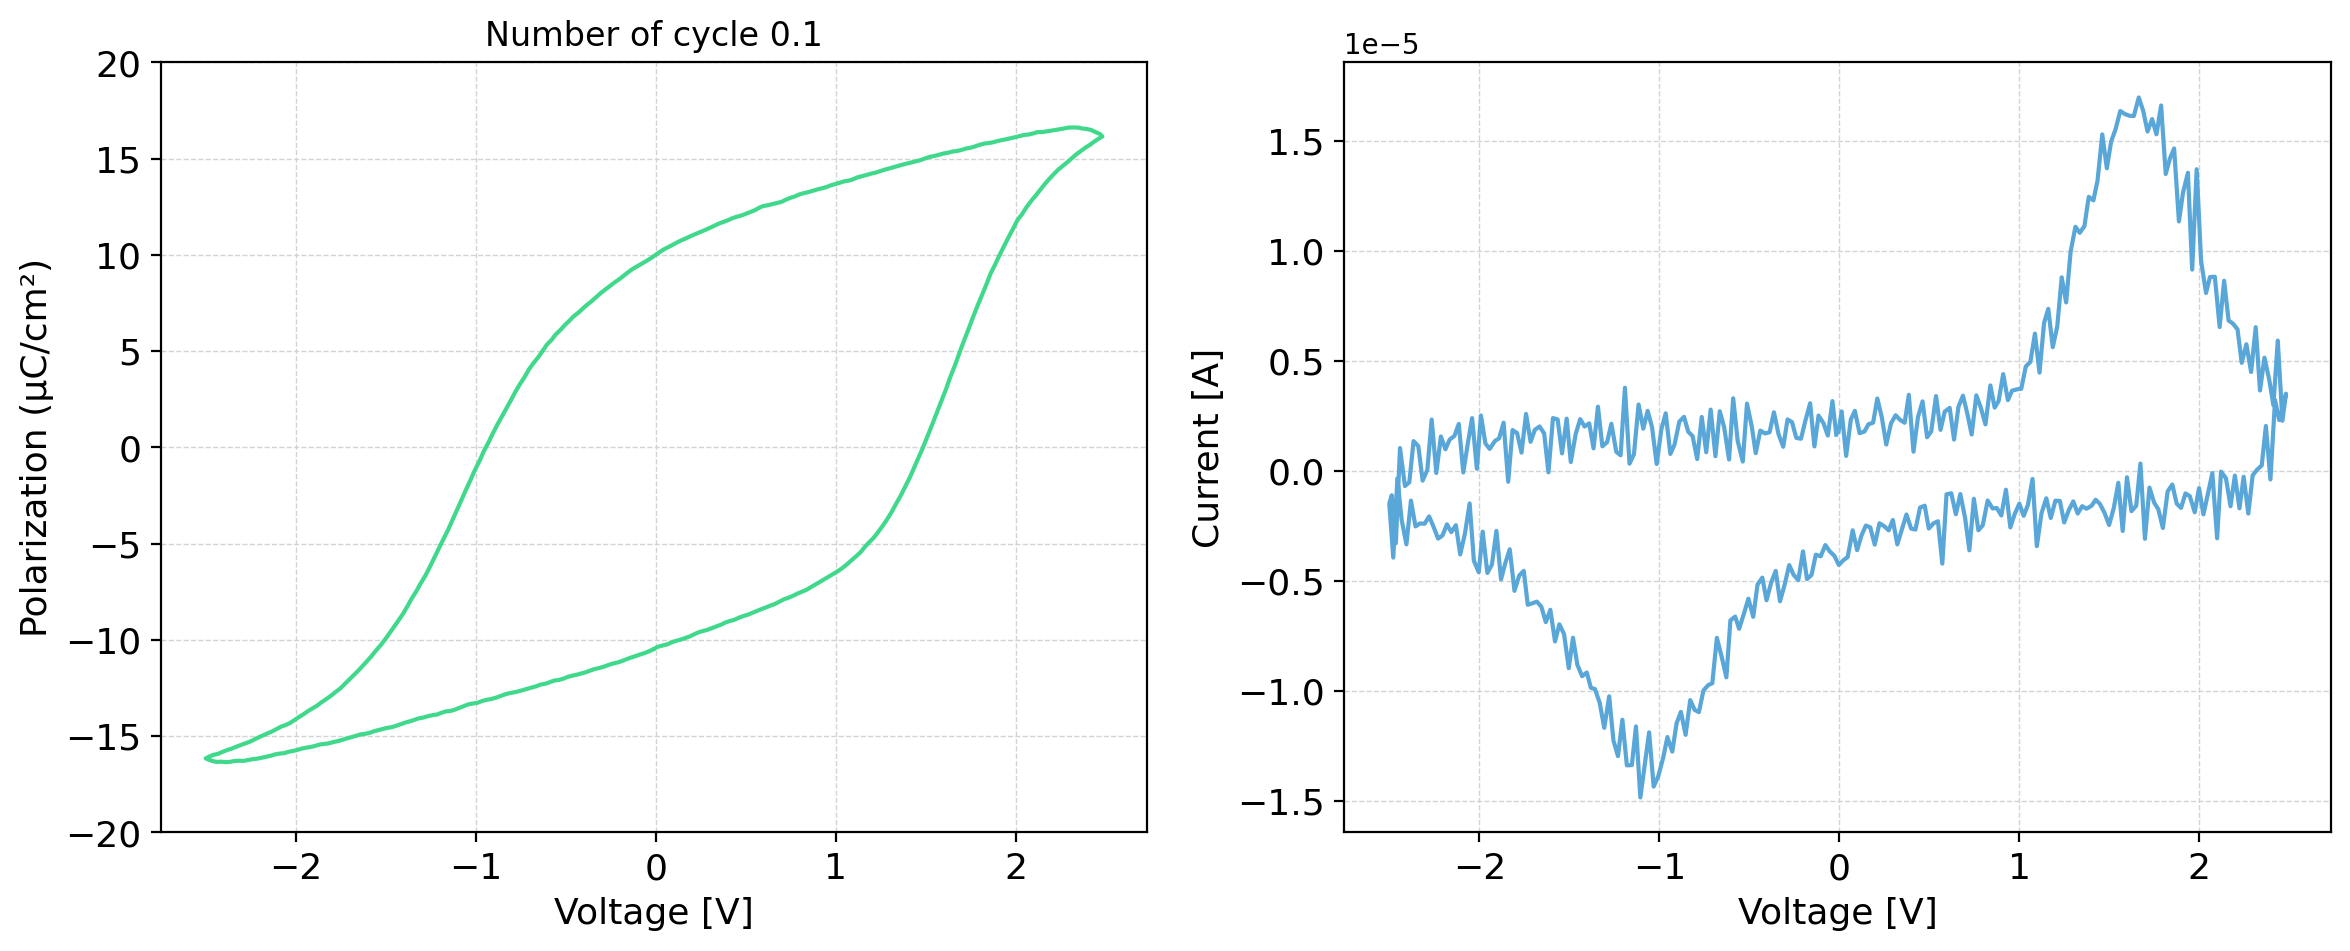

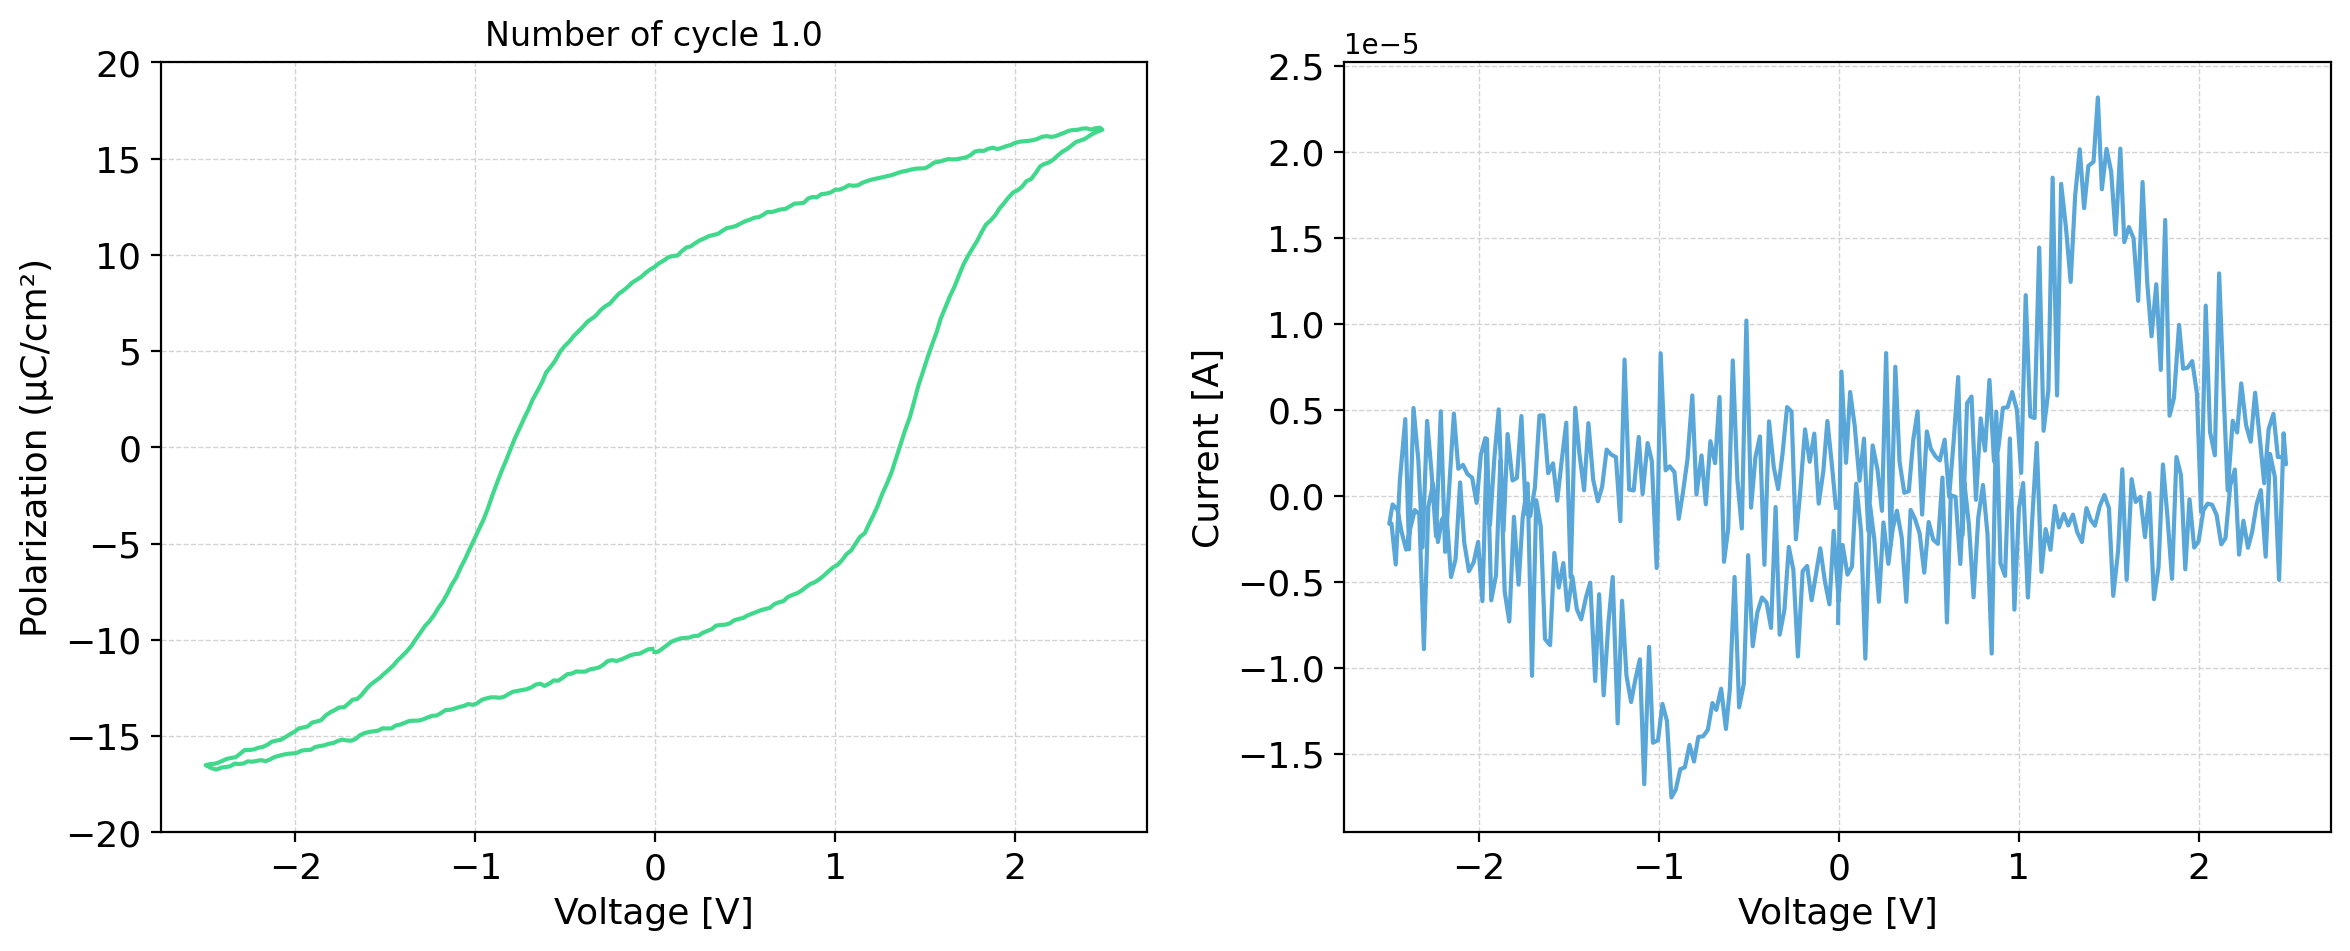

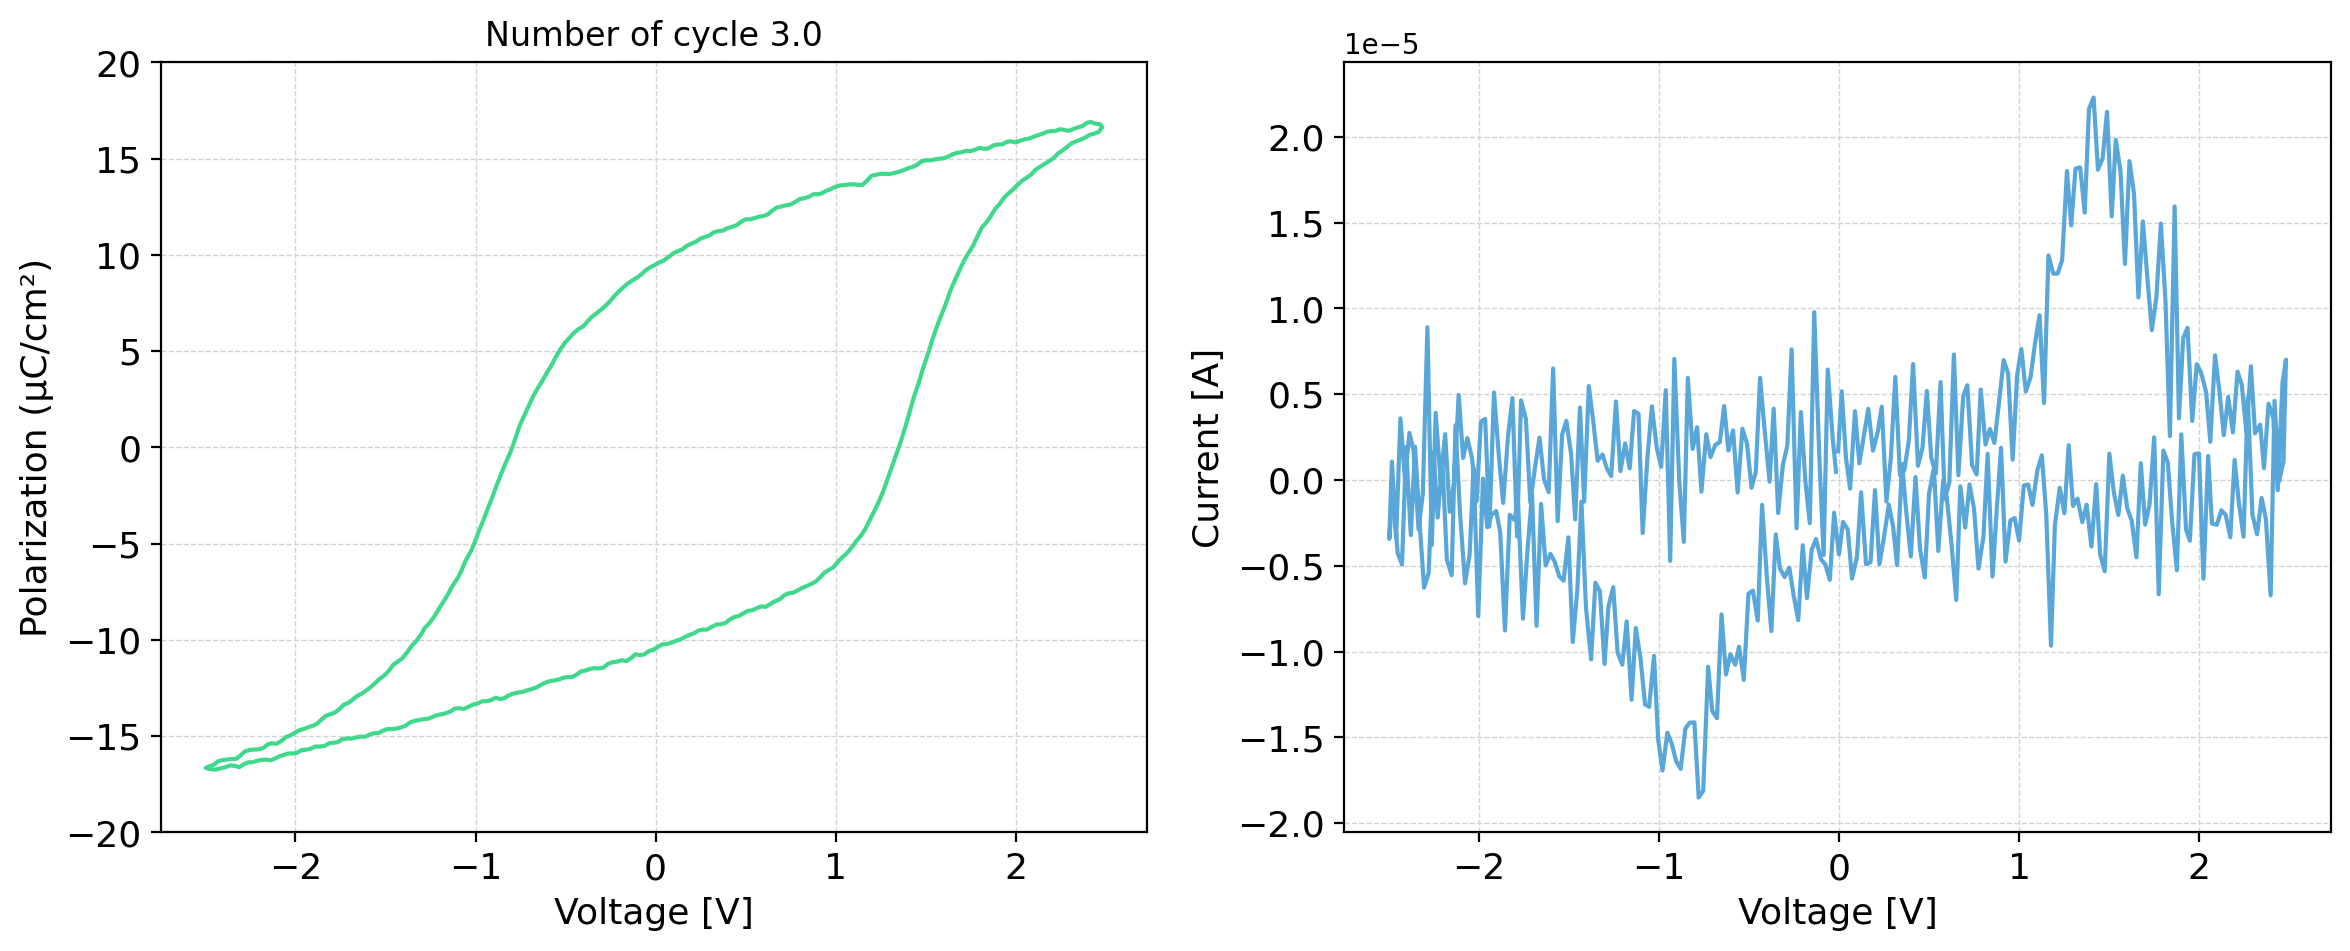

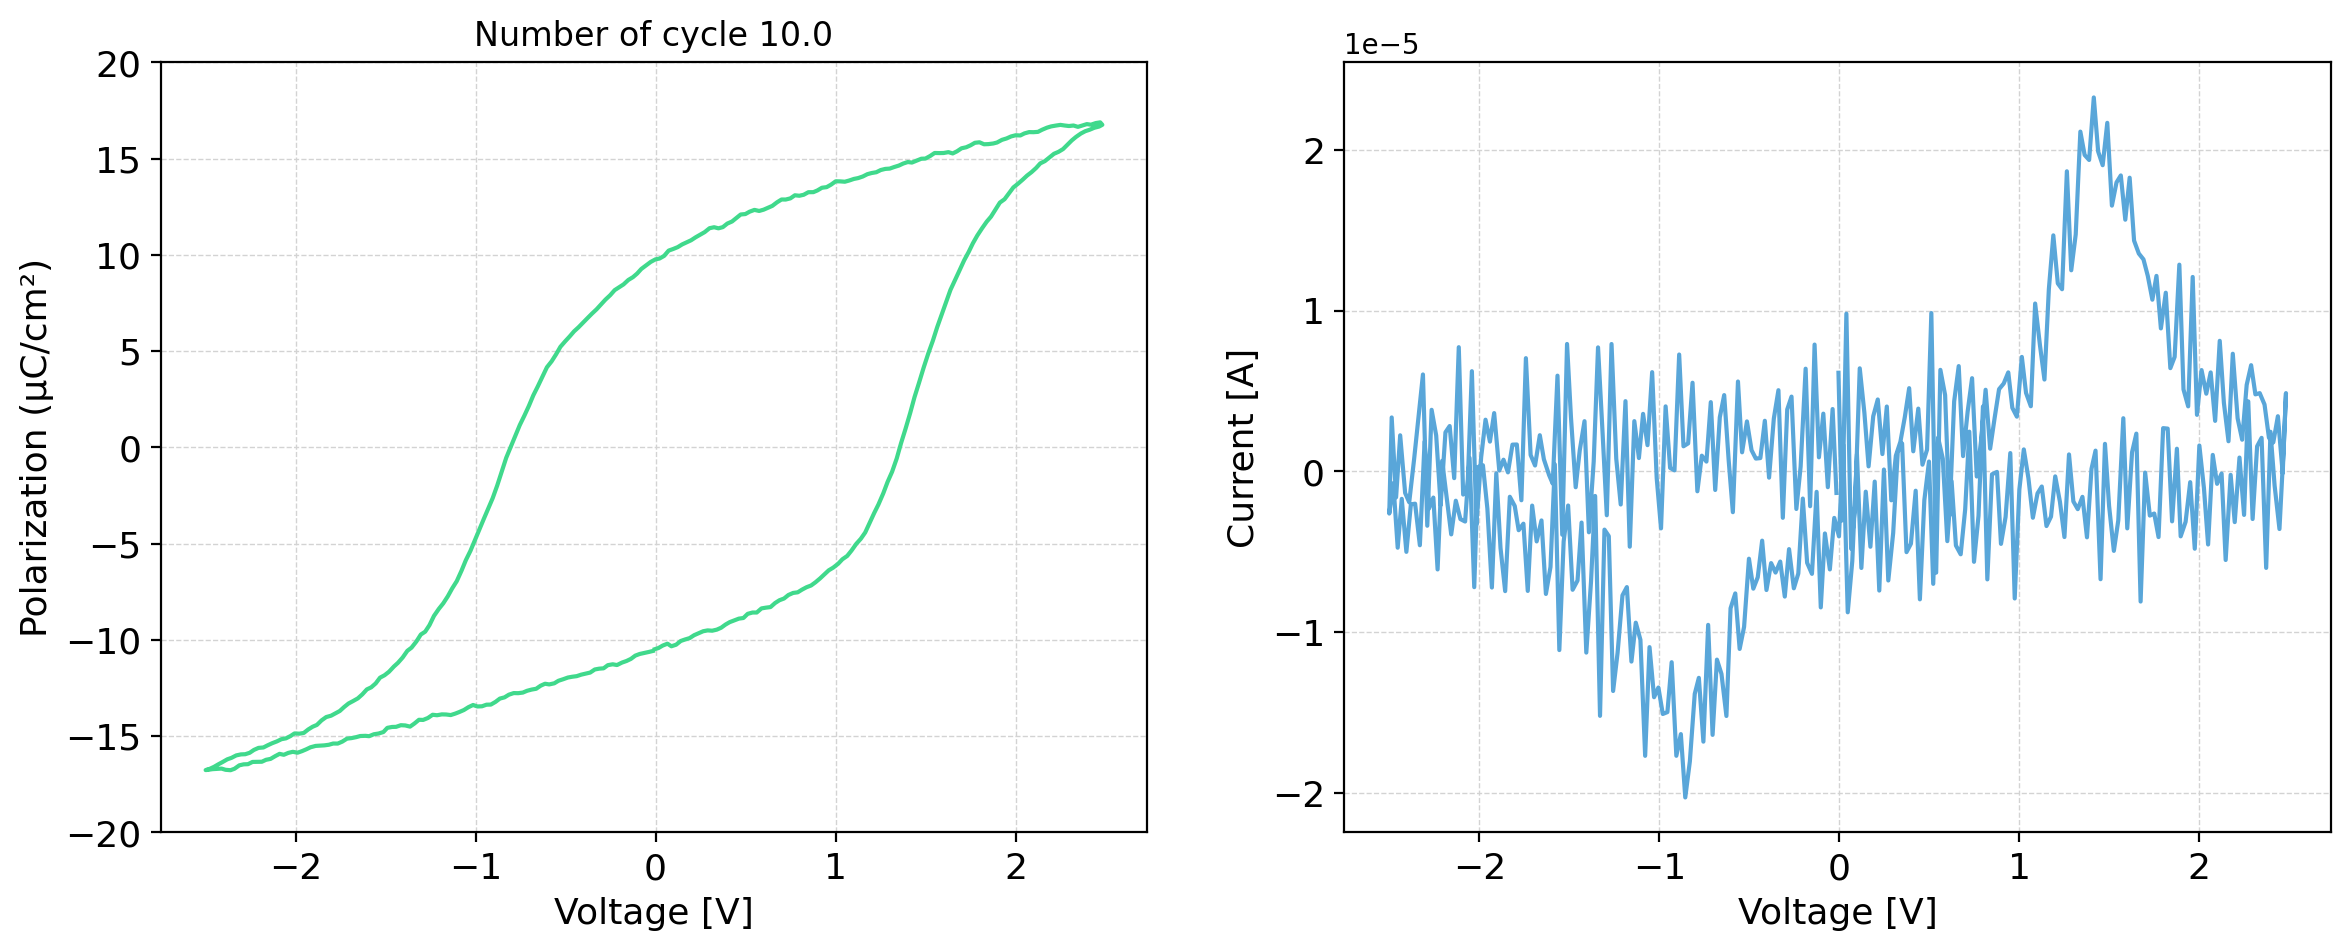

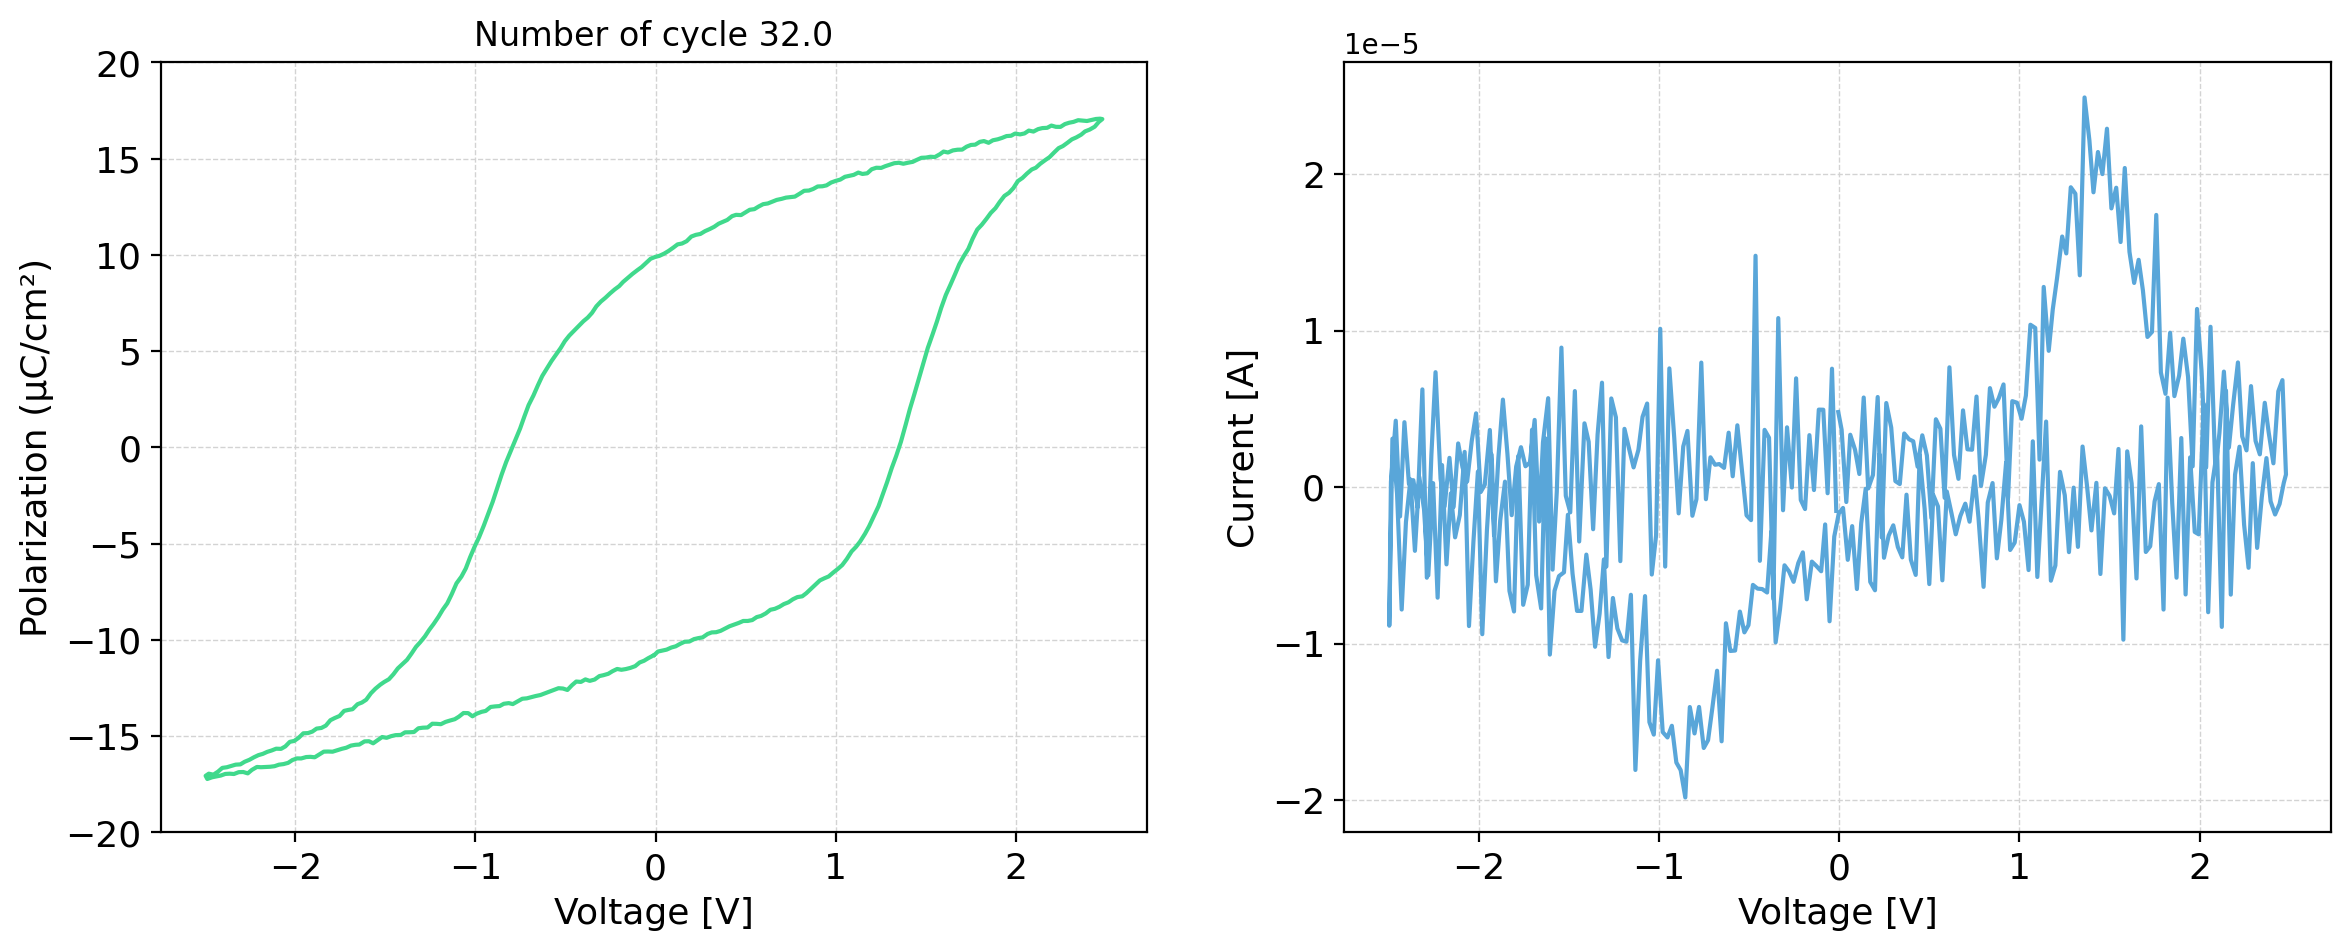

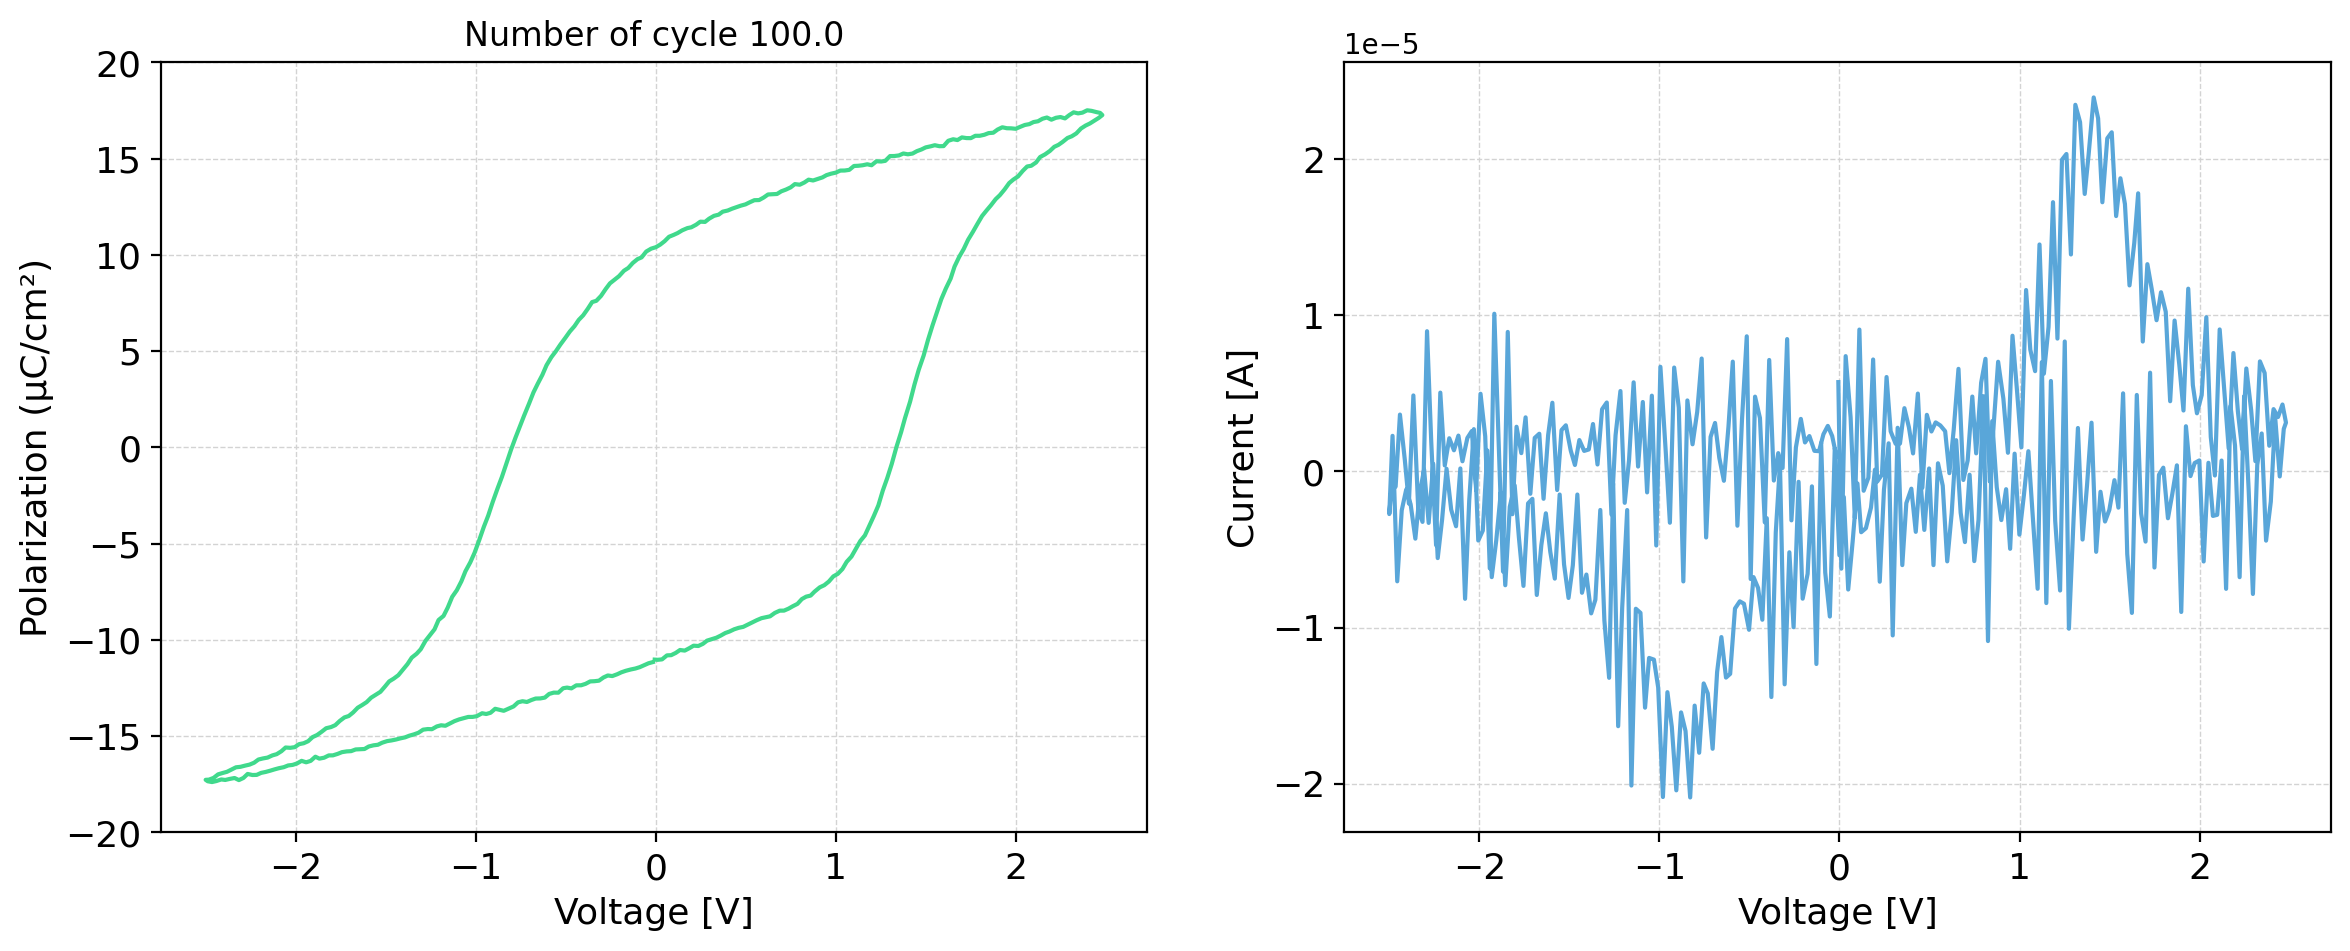

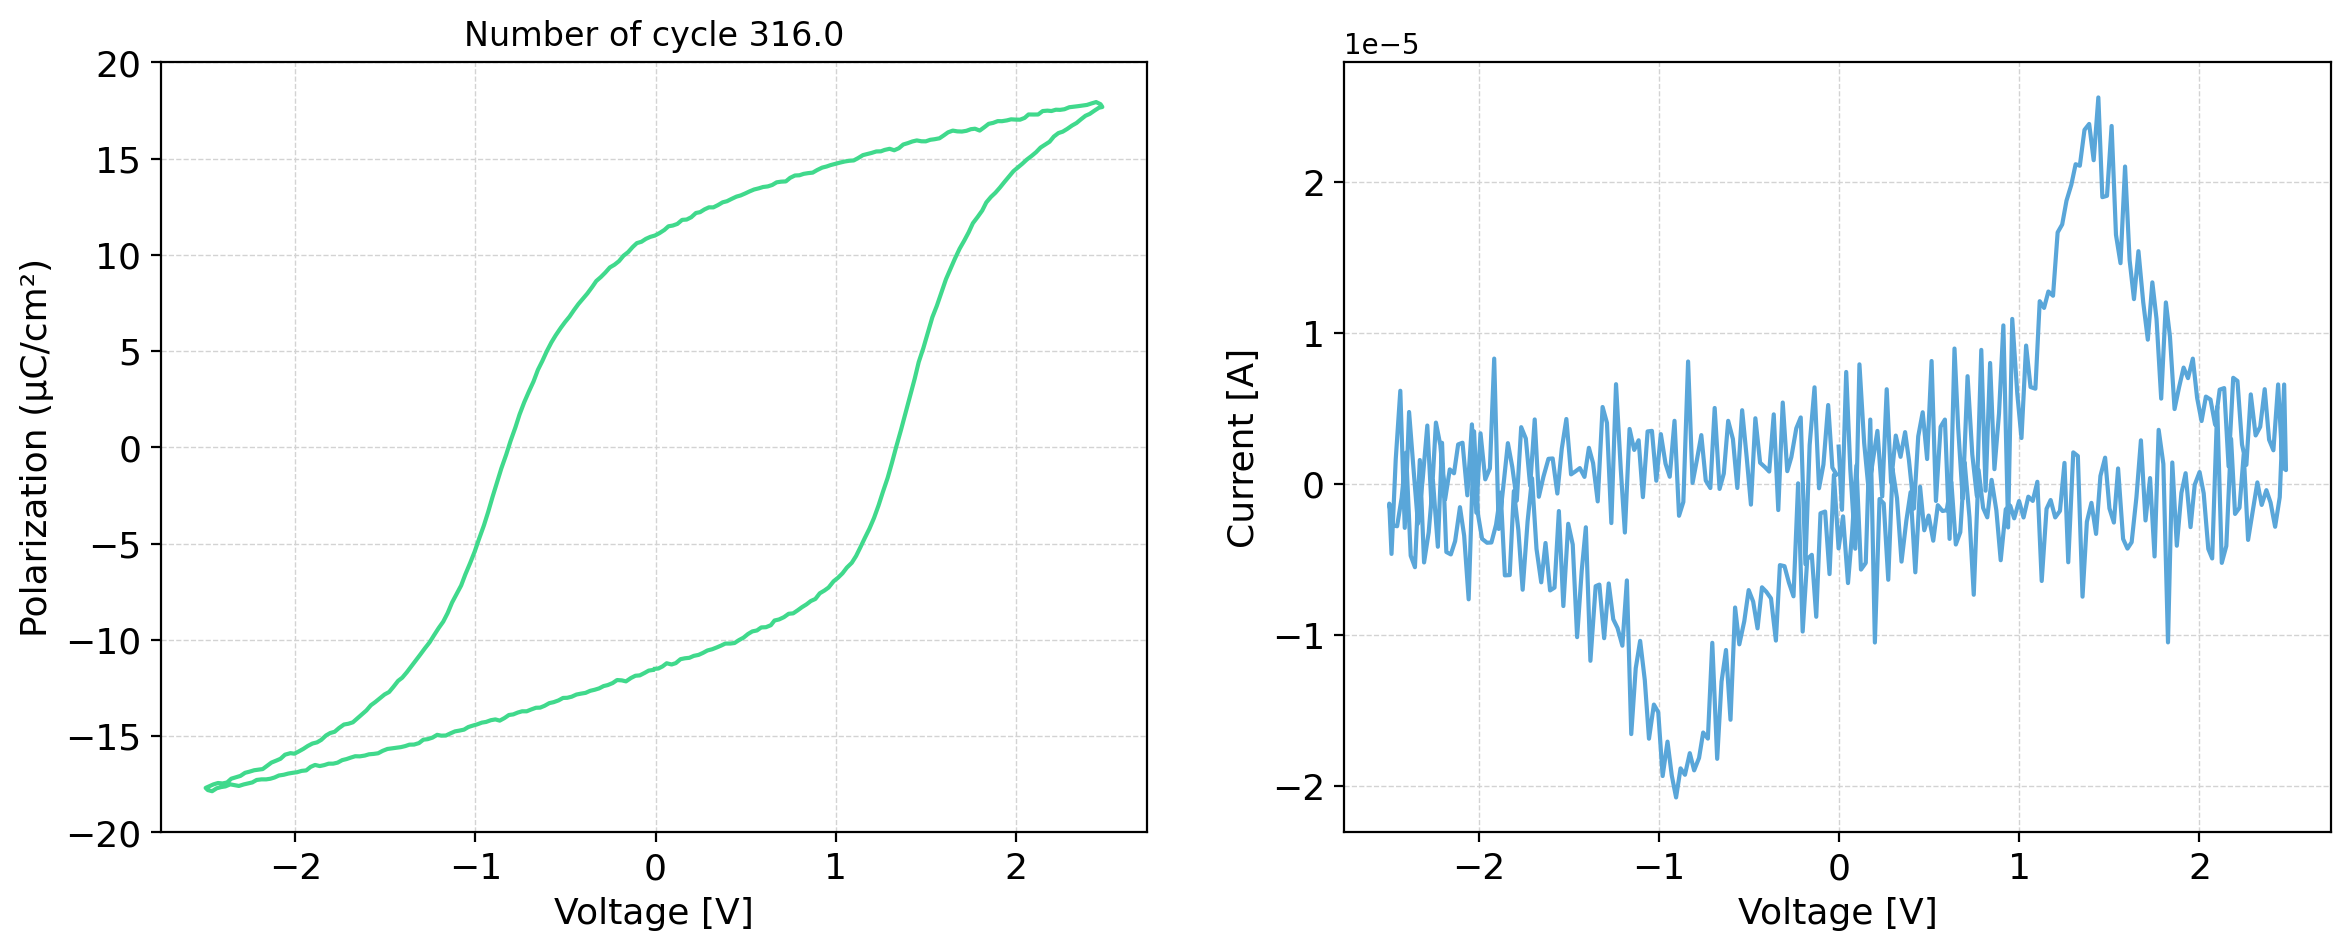

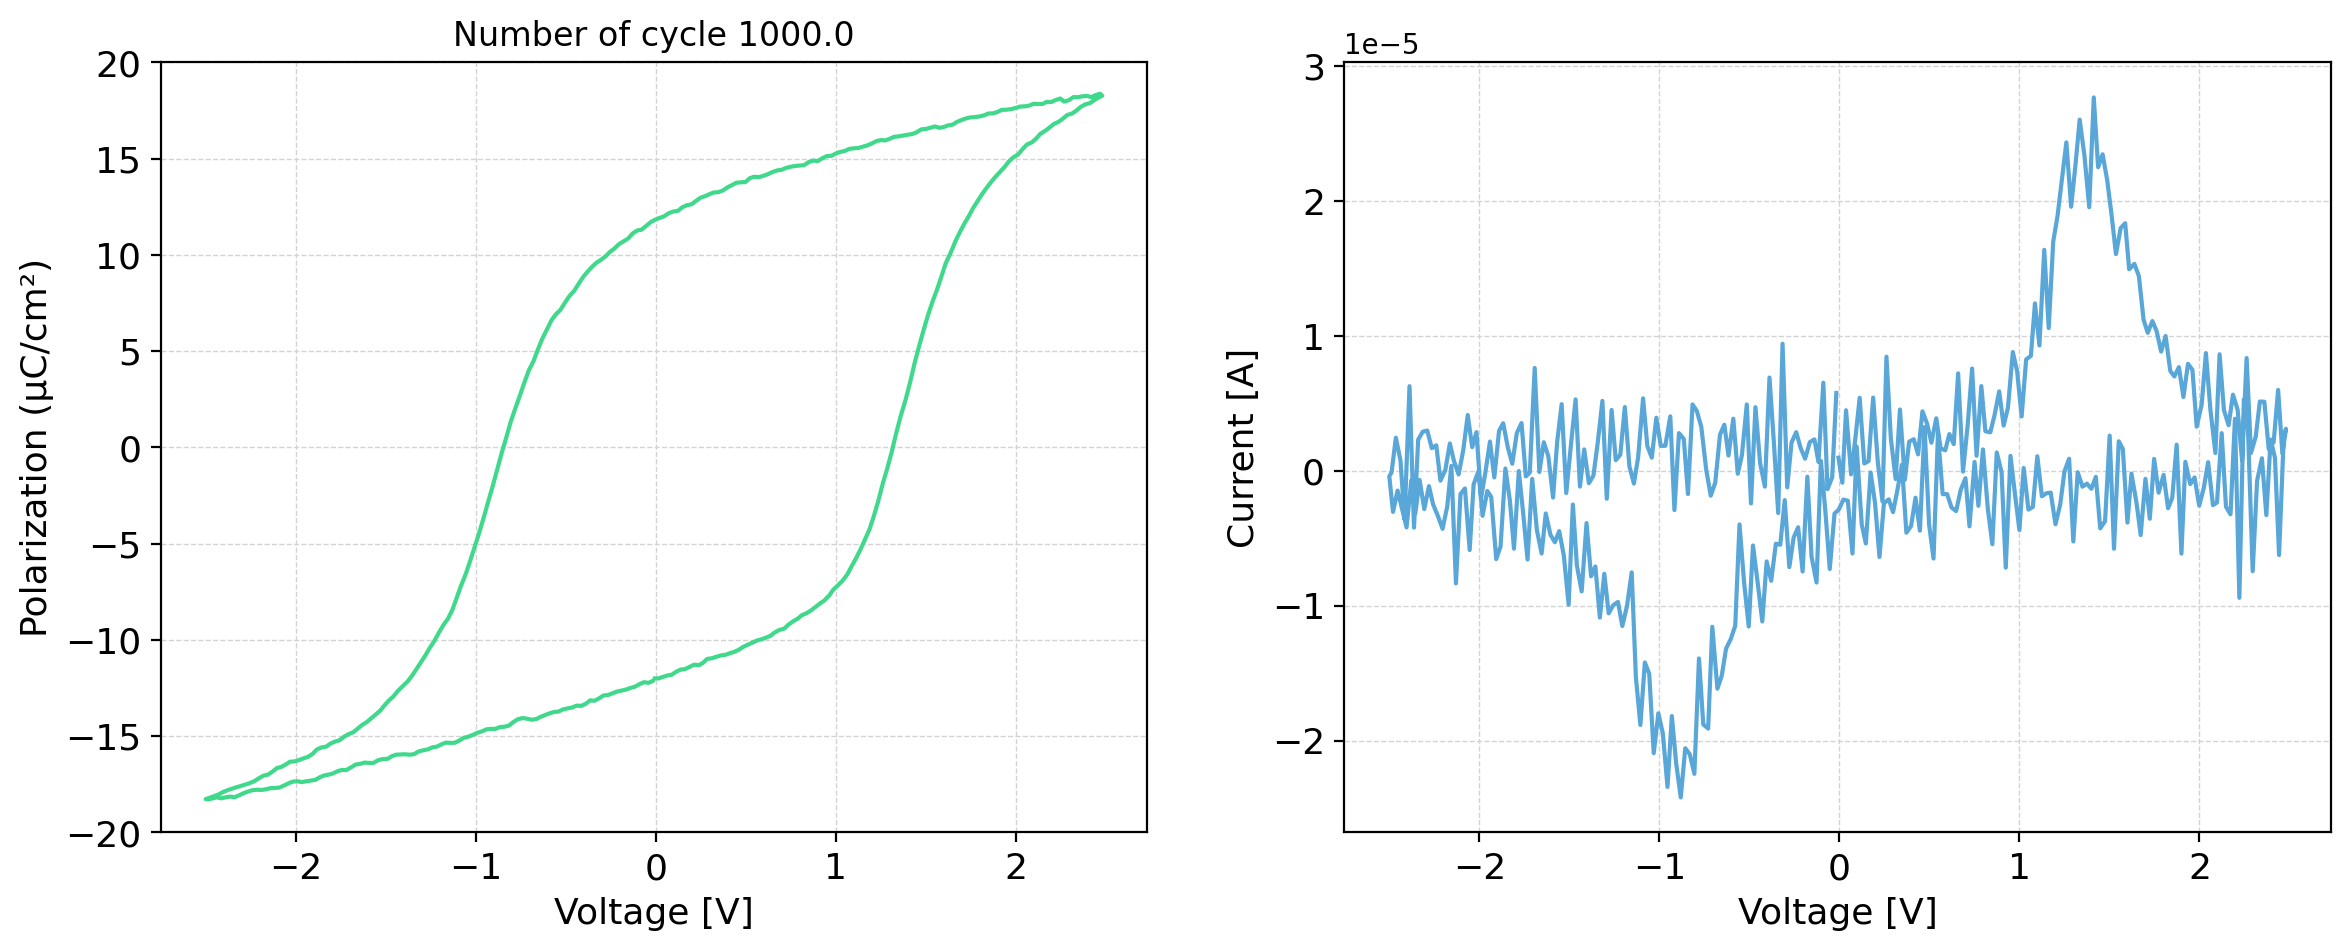

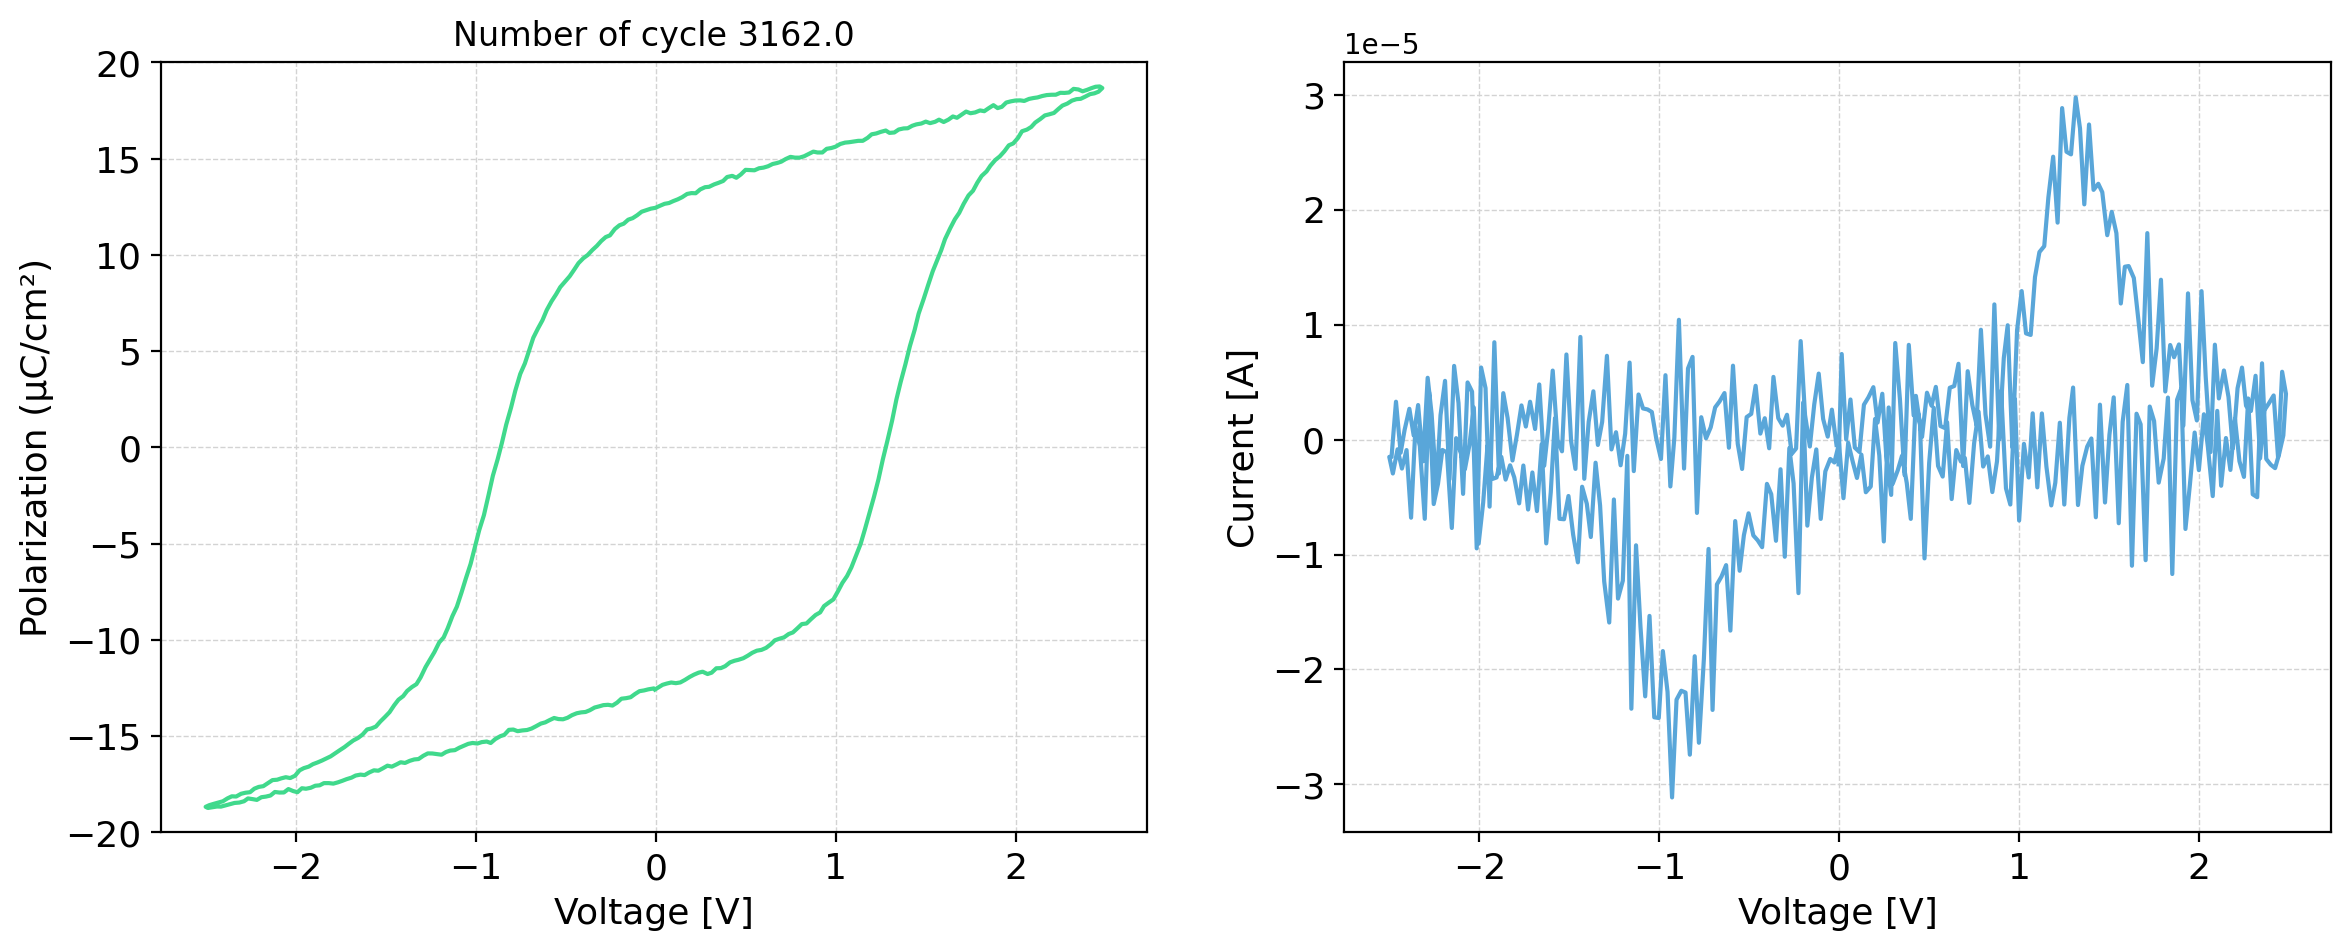

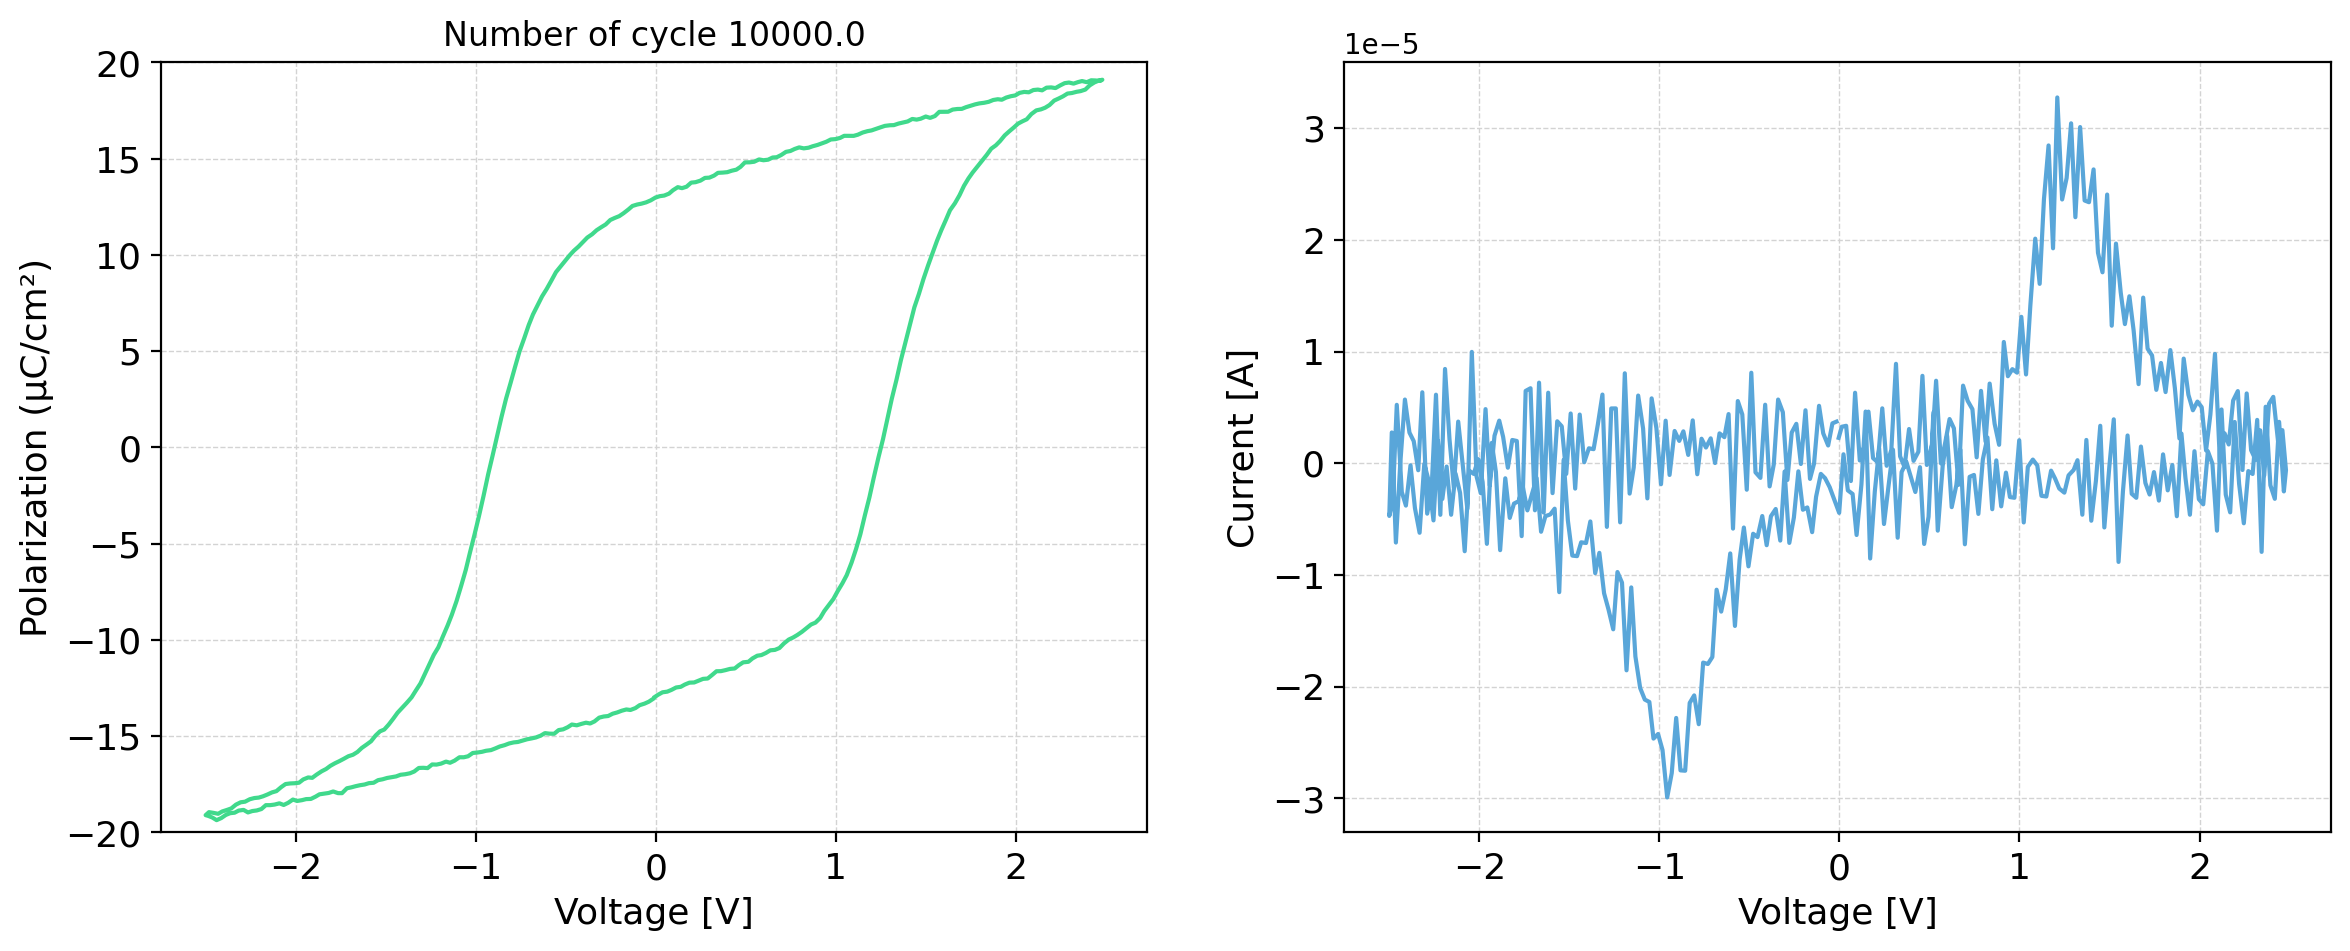

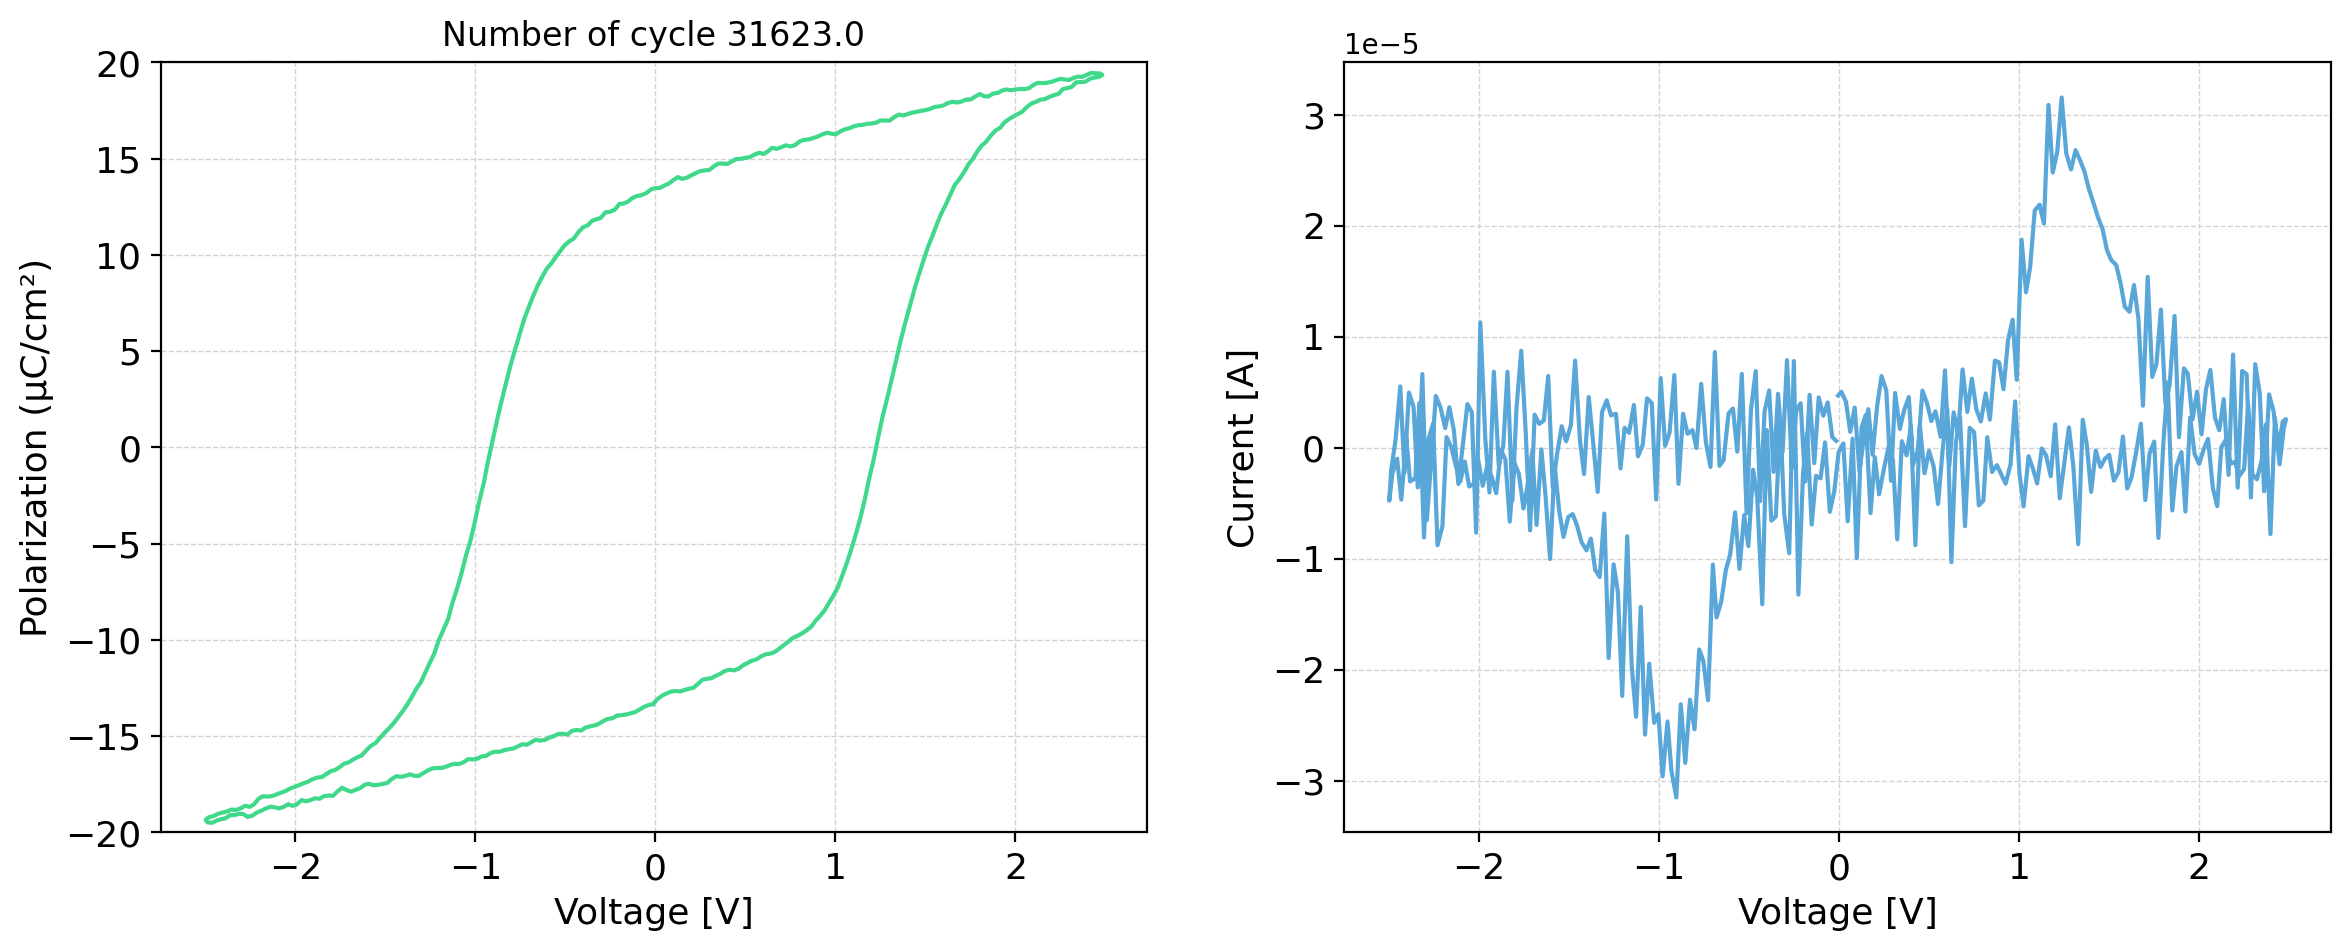

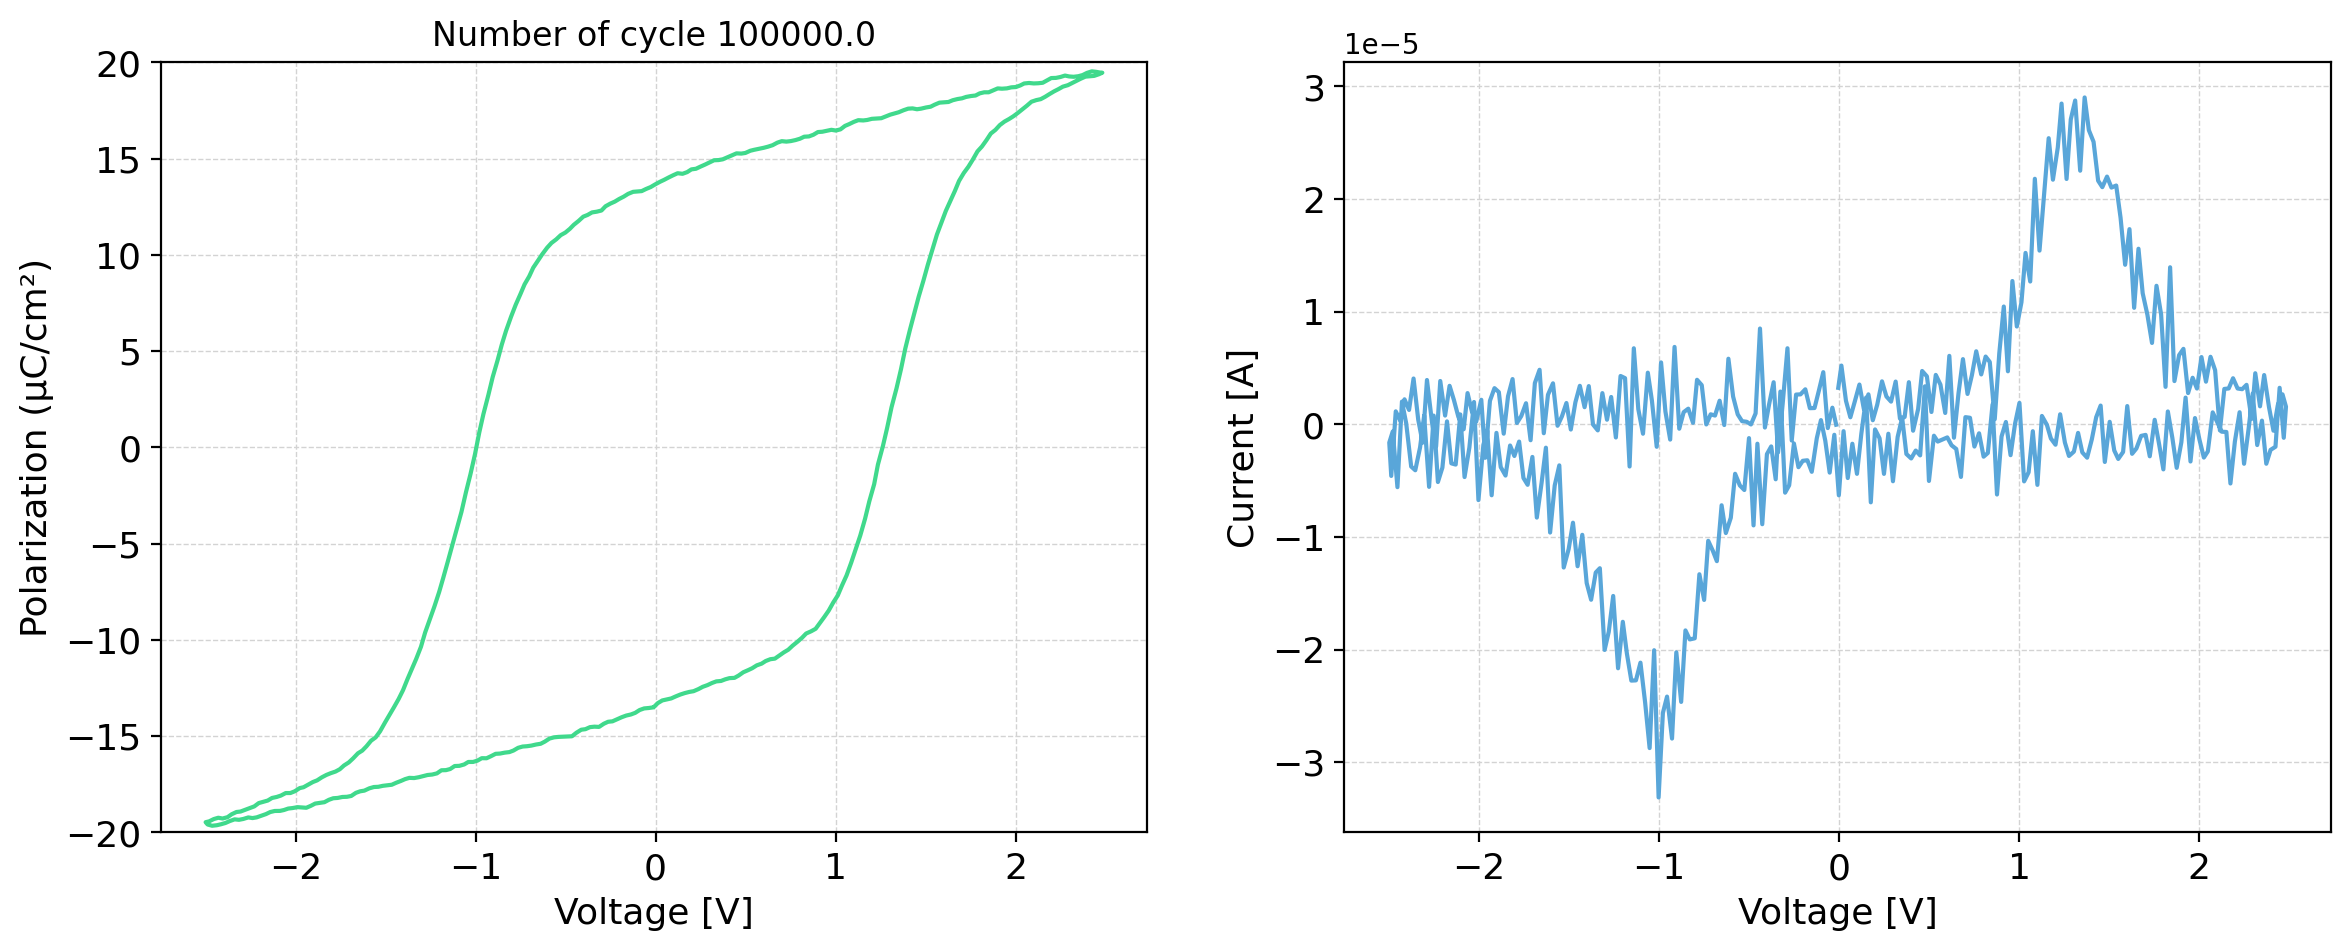

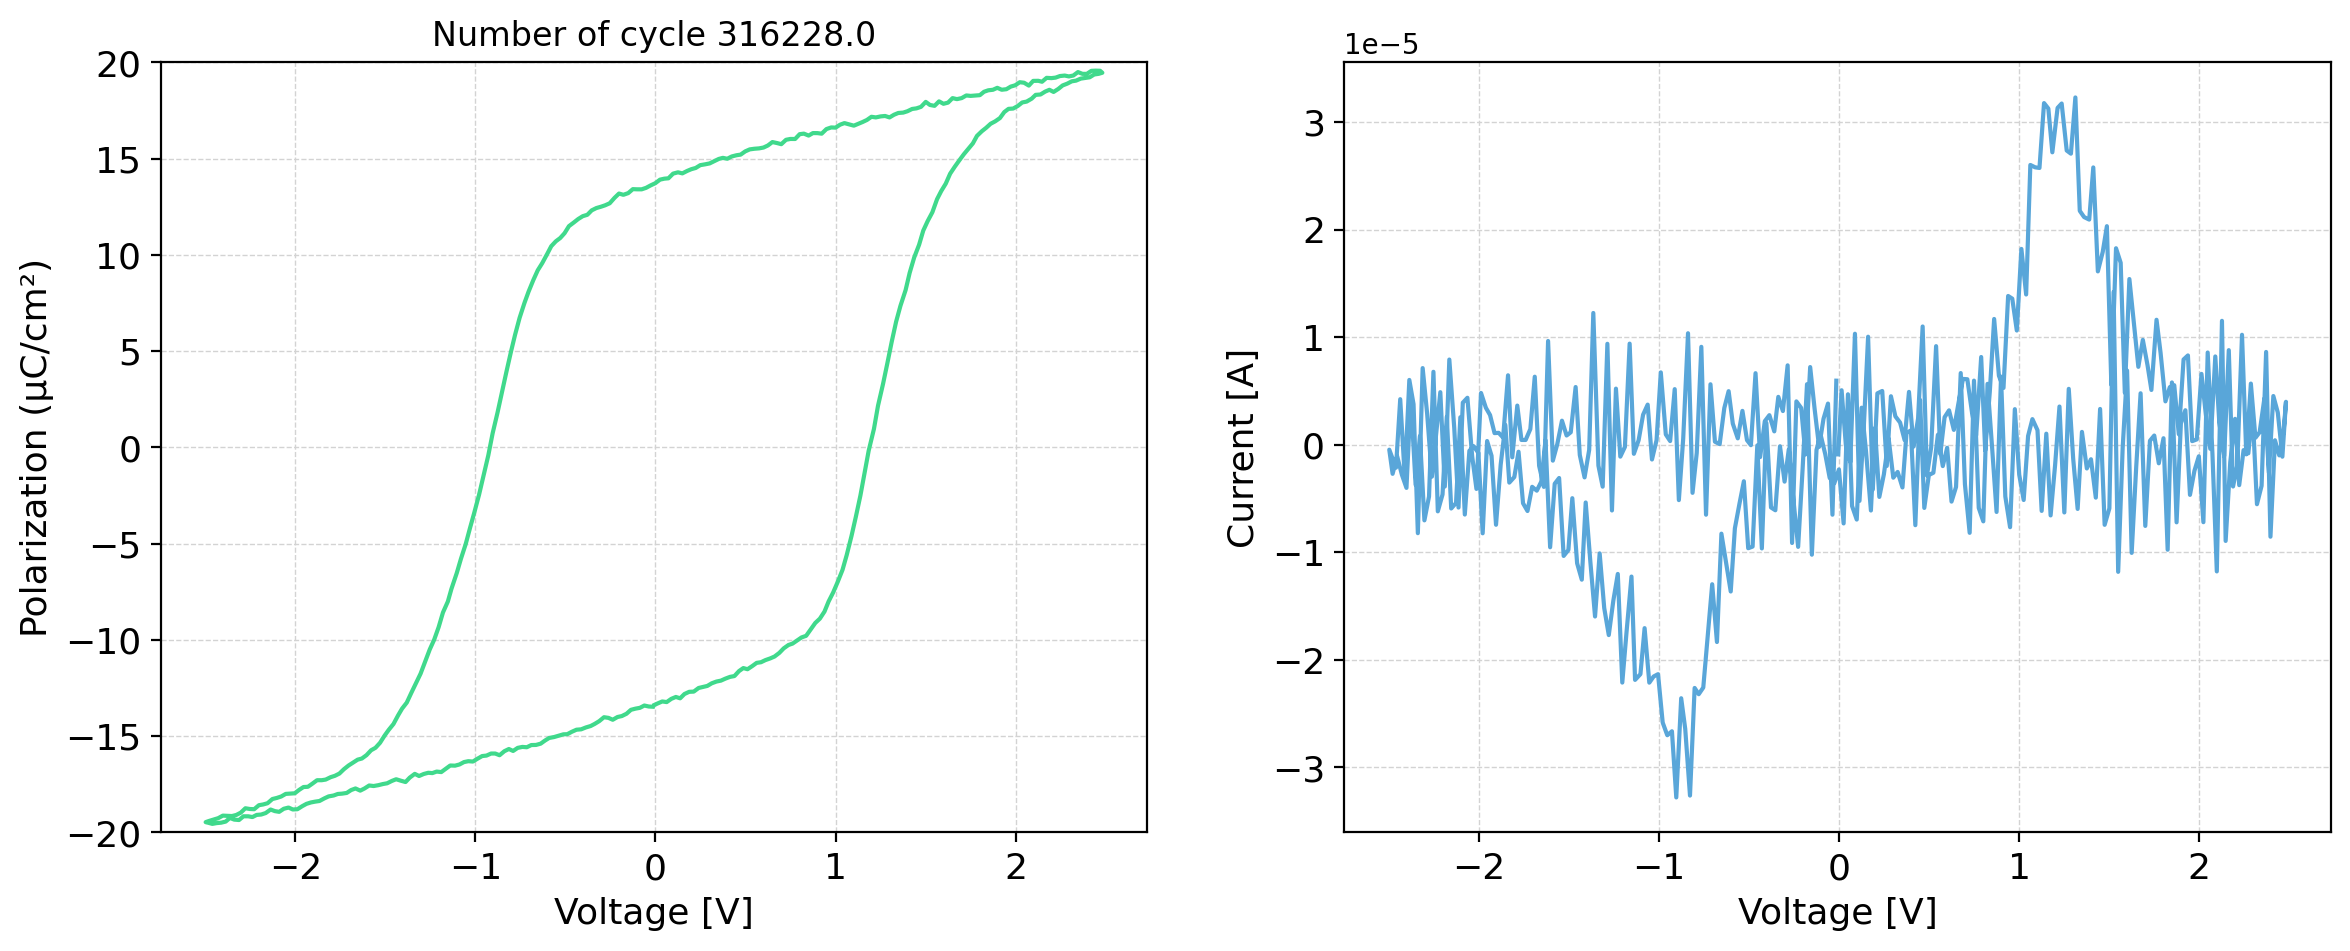

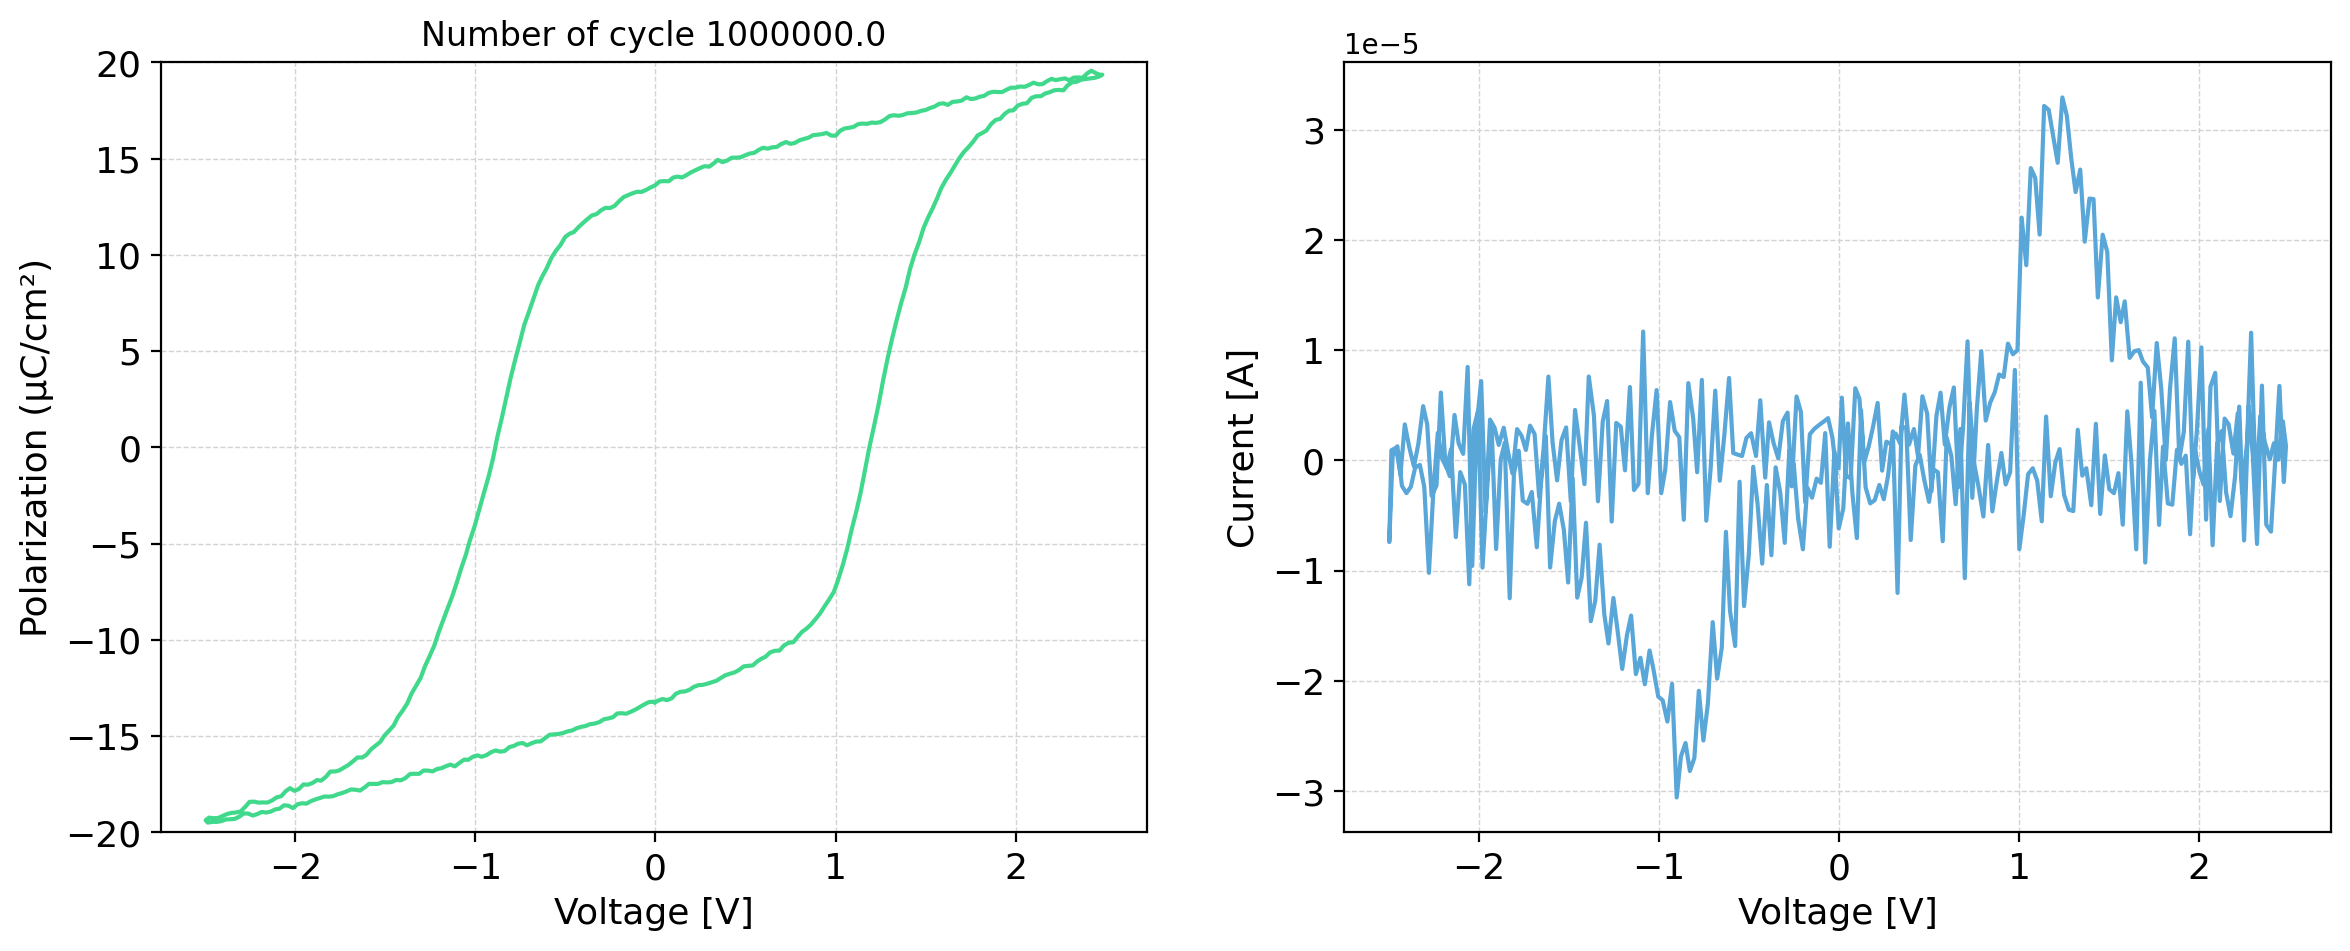

In [14]:
# Plot of every DHM curve.

label_size = 13
Plot_multi_DHM(DHM_dataframe,output_path_02, Cycles_total, label_size, base_name)

if video_allowed == 1:
    # --- Create a video from the DHM plots ---

    output_plot = os.path.join(output_path_02, "DHM plot")
    output_video = os.path.join(output_path_02, "Video")
    os.makedirs(output_plot, exist_ok=True)  # Ensure output directory exists
    os.makedirs(output_video, exist_ok=True)  # Ensure output directory exists

    # === Paramètres à donner par l’opérateur ===
    fps = 11   # images par seconde (modifiable)
    outfile = "dhm_fatigue.mp4"
    output_video = os.path.join(output_video, outfile)

    # Récupère et trie les fichiers PNG
    files = natsort.natsorted(glob.glob(os.path.join(output_plot, "*.png")))

    if not files:
        raise ValueError(f"❌ Aucun fichier .png trouvé dans {output_plot}")

    # Création de la vidéo
    clip = ImageSequenceClip(files, fps=fps)
    clip.write_videofile(output_video, codec="libx264", audio=False, fps=fps)

    print(f"✅ Vidéo générée : {outfile}")
